<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">DATOS MASIVOS II · PRÁCTICA</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Reglas de asociación en Online Retail II con FP-Growth</div><div style="opacity:.72;font-size:14px;margin-top:6px;">Canastas de compra por factura, itemsets frecuentes y reglas por trimestre, a partir de las ventas limpias.</div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

### Objetivo

Encontrar **qué productos se compran juntos** en la tienda en línea de *Online Retail II* y comprobar si esas asociaciones
se mantienen o cambian a lo largo del tiempo. Cada factura se trata como una canasta de compra. Con **FP-Growth** se
obtienen los conjuntos de productos frecuentes y, a partir de ellos, reglas del tipo *"quien compra A también compra B"*,
evaluadas con soporte, confianza y lift. El análisis se hace **por trimestre** para separar los patrones estables de los
que dependen de la temporada; la tienda vende sobre todo regalos y adornos.

### Los datos

UCI Machine Learning Repository, [Online Retail II (id 502)](https://archive.ics.uci.edu/dataset/502/online+retail+ii).
Se usa `data/processed/retail_ventas.parquet`, generado por `01_eda_calidad_preprocesamiento.ipynb`. Son las ventas
reales, **sin** cancelaciones, filas con precio 0, ajustes de inventario, códigos que no son productos ni duplicados. En este notebook no se hace limpieza, solo se hacen algunas modificaciones para la correcta implementación del algoritmo. 

### Contenido

1. **El conjunto de ventas**: dimensiones y facturas por semana.
2. **De facturas a canastas**: codificación dispersa, tamaño de canasta, frecuencia de los productos y un hallazgo de
   calidad (las facturas sin `Customer ID` y la explosión combinatoria que provocan).
3. **Separación por trimestre** y limitaciones de los trimestres incompletos.
4. **FP-Growth y elección del soporte mínimo** con un barrido por trimestre.
5. **Itemsets frecuentes** por trimestre.
6. **Reglas de asociación** por longitud y su redundancia.
7. **Comparación entre trimestres**: reglas persistentes y estacionales.
8. **Evaluación crítica**: variantes del mismo producto, respaldo débil, redundancia y causalidad.
9. **Conclusiones y limitaciones.**

In [28]:
# Librerías, rutas, paleta y funciones auxiliares de estilo
import re
import time
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import StrMethodFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# mlxtend crea DataFrames dispersos con un fill_value que pandas marca como obsoleto; el aviso no afecta el resultado
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 80)

RUTA_PROCESADOS = Path("..") / "data" / "processed"

# Paleta única del notebook: azul principal, rojo de acento y grises neutros
AZUL, ROJO = "#3D6FB0", "#B03D3D"
GRIS, GRIS_CLARO, TINTA = "#8C8C8C", "#EEF1F6", "#333333"
# Longitud de itemset o regla (orden fijo; pares adyacentes verificados para daltonismo)
COLOR_LONGITUD = {"1": AZUL, "2": "#EB6834", "3": "#1BAF7A", "4+": "#4A3AA7"}
MARCADOR_LONGITUD = {"2": "o", "3": "^", "4+": "s"}
# Escala secuencial de un solo tono (azules) para lift, conteos y similitudes; vacío = blanco
CMAP_SEC = LinearSegmentedColormap.from_list("azules", plt.cm.Blues(np.linspace(0.22, 1, 256)))
CMAP_SEC.set_bad("white")

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.edgecolor": "#999999", "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA, "legend.frameon": False,
})


def estilo_ejes(ax, titulo=None, xlabel=None, ylabel=None, rejilla="y"):
    """
    Aplica el estilo común a unos ejes de matplotlib.

    Parámetros
    ----------
    ax : matplotlib.axes.Axes
        Ejes a formatear.
    titulo, xlabel, ylabel : str, opcional
        Título y etiquetas de los ejes (con unidades).
    rejilla : {"x", "y", "both", None}
        Eje sobre el que se dibuja una rejilla tenue.
    """
    if titulo:
        ax.set_title(titulo)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    if rejilla:
        ax.grid(axis=rejilla, color="#DDDDDD", linewidth=0.6)
        ax.set_axisbelow(True)


def etiqueta_trimestre(fechas):
    """
    Convierte fechas en etiquetas de trimestre del tipo '1T-2010'.

    Parámetros
    ----------
    fechas : pd.Series
        Serie de tipo datetime.

    Retorna
    -------
    pd.Series
        Etiquetas de trimestre como texto.
    """
    periodo = fechas.dt.to_period("Q")
    return periodo.dt.quarter.astype(str) + "T-" + periodo.dt.year.astype(str)


def conteo_columnas(X):
    """
    Cuenta en cuántas filas (facturas) aparece cada columna (producto) de una matriz one-hot dispersa.

    Parámetros
    ----------
    X : pd.DataFrame
        DataFrame disperso de booleanos.

    Retorna
    -------
    pd.Series
        Conteo entero por columna.
    """
    return pd.Series(np.asarray(X.sparse.to_coo().sum(axis=0)).ravel(), index=X.columns)


MARCAS_LIFT = [1, 2, 3, 5, 10, 20, 50, 80]


def marcas_log(eje, vmin, vmax, marcas=MARCAS_LIFT):
    """
    Pone marcas legibles (números enteros) en un eje logarítmico de matplotlib.

    Parámetros
    ----------
    eje : matplotlib.axis.Axis o matplotlib.colorbar.Colorbar
        Eje x/y o barra de color a formatear.
    vmin, vmax : float
        Rango visible; solo se usan las marcas que caen dentro.
    marcas : list of float
        Marcas candidatas.
    """
    dentro = [m for m in marcas if vmin <= m <= vmax]
    eje.set_ticks(dentro, labels=[f"{m:g}" for m in dentro])
    if hasattr(eje, "minorticks_off"):
        eje.minorticks_off()
    else:
        eje.set_minor_formatter(plt.NullFormatter())


def pct(x, dec=2):
    """Formatea una proporción como porcentaje con espacio antes del símbolo."""
    return f"{100 * x:,.{dec}f} %"

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · DATOS</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. El conjunto de ventas</span></div>


Cada fila de `retail_ventas` es una **línea de factura**:
un producto (`StockCode`) dentro de una factura (`Invoice`), con su cantidad, precio, fecha, cliente y país. Para el
análisis de canasta, la unidad que importa es la **factura**, no la línea. Por eso la tabla siguiente distingue entre
líneas, facturas, clientes y productos, e informa cuántas facturas no tienen `Customer ID`.

In [29]:
# Carga de las ventas limpias y resumen de dimensiones
ventas = pd.read_parquet(RUTA_PROCESADOS / "retail_ventas.parquet")


def resumen_dataset(df):
    """
    Resume las dimensiones de un conjunto de líneas de venta en una tabla Métrica/Valor.

    Parámetros
    ----------
    df : pd.DataFrame
        Líneas de venta con columnas Invoice, StockCode, InvoiceDate, Customer ID y Country.

    Retorna
    -------
    pd.DataFrame
        Una fila por métrica: líneas, facturas, clientes, faltantes de Customer ID, productos, países y fechas.
    """
    lineas_con_cliente = df.groupby("Invoice")["Customer ID"].count()
    fact_sin = int((lineas_con_cliente == 0).sum())
    lin_sin = int(df["Customer ID"].isna().sum())
    inicio, fin = df["InvoiceDate"].min(), df["InvoiceDate"].max()
    filas = {
        "Líneas (filas)": f"{len(df):,}",
        "Facturas (Invoice)": f"{df['Invoice'].nunique():,}",
        "Clientes distintos (Customer ID)": f"{df['Customer ID'].nunique():,}",
        "Líneas sin Customer ID": f"{lin_sin:,} ({pct(lin_sin / len(df))})",
        "Facturas sin Customer ID": f"{fact_sin:,} ({pct(fact_sin / len(lineas_con_cliente))})",
        "Productos distintos (StockCode)": f"{df['StockCode'].nunique():,}",
        "Países (Country)": f"{df['Country'].nunique():,}",
        "Rango de fechas": f"{inicio:%d/%m/%Y %H:%M} – {fin:%d/%m/%Y %H:%M}",
        "Días naturales / días con ventas": f"{(fin - inicio).days + 1:,} / {df['InvoiceDate'].dt.date.nunique():,}",
    }
    return pd.Series(filas, name="Valor").rename_axis("Métrica").to_frame()


display(resumen_dataset(ventas))

# Una factura pertenece a un solo cliente: se comprueba antes de usar la factura como transacción
por_factura = ventas.groupby("Invoice")["Customer ID"].agg(["count", "size", "nunique"])
print(f"Facturas con Customer ID parcialmente vacío: {((por_factura['count'] > 0) & (por_factura['count'] < por_factura['size'])).sum()} | "
      f"facturas con más de un cliente: {(por_factura['nunique'] > 1).sum()}")
print("\nMuestra de filas:")
display(ventas.sample(8, random_state=42))

,Valor
Métrica,
Líneas (filas),"1,003,357"
Facturas (Invoice),"39,516"
Clientes distintos (Customer ID),"5,852"
Líneas sin Customer ID,"226,761 (22.60 %)"
Facturas sin Customer ID,"2,922 (7.39 %)"
Productos distintos (StockCode),"4,726"
Países (Country),43
Rango de fechas,01/12/2009 07:45 – 09/12/2011 12:50
Días naturales / días con ventas,739 / 604


Facturas con Customer ID parcialmente vacío: 0 | facturas con más de un cliente: 0

Muestra de filas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
896272,573585,23334,IVORY WICKER HEART SMALL,6,2011-10-31 14:41:00,1.25,<NA>,United Kingdom
967493,578996,23469,CARD HOLDER LOVE BIRD SMALL,4,2011-11-27 16:02:00,4.15,13991,United Kingdom
661844,553013,22678,FRENCH BLUE METAL DOOR SIGN 3,1,2011-05-12 18:19:00,2.46,<NA>,United Kingdom
103199,499769,84908A,PINK 5 PATCH FLOWER CUSHION COVER,24,2010-03-02 13:25:00,1.95,13694,United Kingdom
556811,542906,85116,BLACK CANDELABRA T-LIGHT HOLDER,11,2011-02-01 15:12:00,1.63,<NA>,United Kingdom
482166,536539,22632,HAND WARMER RED RETROSPOT,12,2010-12-01 14:03:00,2.10,15165,United Kingdom
242681,513952,22175,PINK OWL SOFT TOY,2,2010-06-29 14:11:00,2.95,14049,United Kingdom
682611,555257,20685,DOORMAT RED RETROSPOT,1,2011-06-01 15:28:00,7.95,17596,United Kingdom


La serie semanal de facturas muestra cuánta actividad hay en cada parte del periodo y si los trimestres son comparables.
Las franjas alternas delimitan los trimestres. Un trimestre se marca como **incompleto** (trama roja) si la ventana de los
datos (del 01/12/2009 al 09/12/2011) no lo cubre por completo.

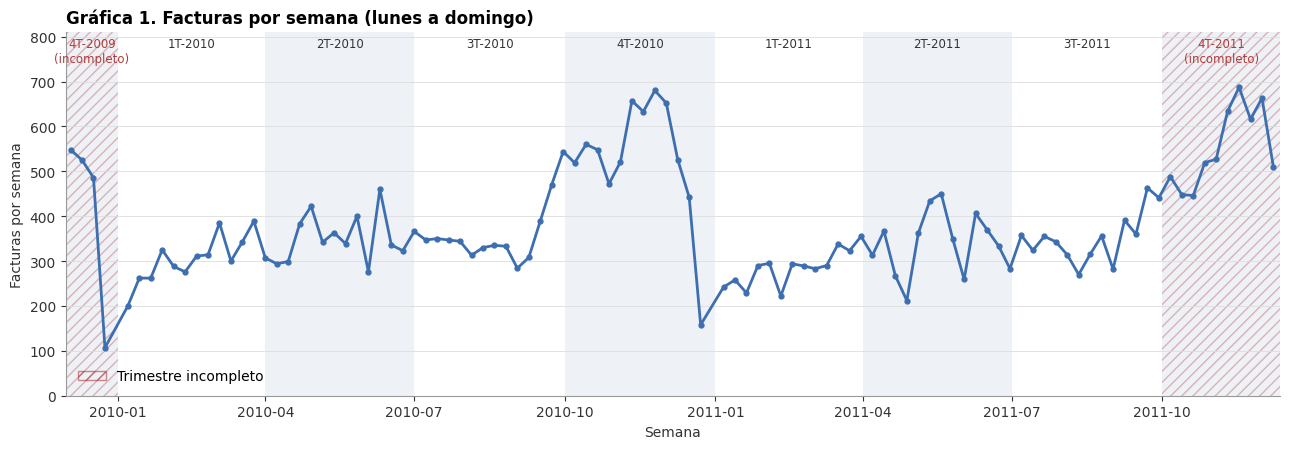

Semanas: 104 | media: 380.0 facturas | mínimo: 107 (semana del 21/12/2009) | máximo: 687 (semana del 14/11/2011)
Semanas con menos de 100 facturas:
Series([], )


In [30]:
# Facturas por semana, con franjas por trimestre y los trimestres incompletos sombreados
INICIO_DATOS, FIN_DATOS = ventas["InvoiceDate"].min(), ventas["InvoiceDate"].max()


def trimestre_completo(periodo):
    """Indica si un trimestre (pd.Period) cae completo dentro de la ventana observada de los datos."""
    return periodo.start_time >= INICIO_DATOS.normalize() and periodo.end_time <= FIN_DATOS


fecha_factura = ventas.groupby("Invoice")["InvoiceDate"].min()
semanal = fecha_factura.dt.to_period("W-SUN").value_counts().sort_index()
x_sem = semanal.index.start_time + pd.Timedelta(days=3)  # punto en el centro de la semana

fig, ax = plt.subplots(figsize=(13, 4.6))
y_max = semanal.max() * 1.18
periodos = pd.period_range(INICIO_DATOS, FIN_DATOS, freq="Q")
for i, p in enumerate(periodos):
    ini, fin = max(p.start_time, semanal.index[0].start_time), min(p.end_time, semanal.index[-1].end_time)
    completo = trimestre_completo(p)
    ax.axvspan(ini, fin, facecolor=GRIS_CLARO if i % 2 == 0 else "white", edgecolor="none", zorder=0)
    if not completo:
        ax.axvspan(ini, fin, facecolor="none", edgecolor=ROJO, hatch="///", linewidth=0, alpha=0.35, zorder=0)
    etiqueta = f"{p.quarter}T-{p.year}" + ("\n(incompleto)" if not completo else "")
    ax.text(ini + (fin - ini) / 2, y_max * 0.985, etiqueta, ha="center", va="top", fontsize=8.5,
            color=ROJO if not completo else TINTA)
ax.plot(x_sem, semanal.values, color=AZUL, linewidth=2, marker="o", markersize=3.5, zorder=3)
ax.set_ylim(0, y_max)
ax.set_xlim(semanal.index[0].start_time, semanal.index[-1].end_time)
estilo_ejes(ax, "Gráfica 1. Facturas por semana (lunes a domingo)", "Semana", "Facturas por semana")
ax.legend(handles=[Patch(facecolor="none", edgecolor=ROJO, hatch="///", alpha=0.6, label="Trimestre incompleto")],
          loc="lower left")
plt.tight_layout()
plt.show()

print(f"Semanas: {len(semanal)} | media: {semanal.mean():,.1f} facturas | mínimo: {semanal.min()} "
      f"(semana del {semanal.idxmin().start_time:%d/%m/%Y}) | máximo: {semanal.max()} (semana del {semanal.idxmax().start_time:%d/%m/%Y})")
print("Semanas con menos de 100 facturas:")
print(semanal[semanal < 100].rename(lambda p: f"{p.start_time:%d/%m/%Y}").to_string())

**Observaciones: el conjunto de ventas**

- **Tamaño del problema.** Hay **1,003,357 líneas** que forman **39,516 facturas** de **5,852 clientes**, con **4,726
  productos** y **43 países**, del 01/12/2009 al 09/12/2011: **739 días naturales**, de los cuales **604** tienen ventas.
- **Clientes faltantes.** El **22.60 %** de las líneas no tiene `Customer ID`, pero solo el **7.39 %** de las facturas
  (**2,922**).
- **La factura es una transacción válida:** ninguna factura tiene el `Customer ID` vacío solo en algunas líneas, ni más de
  un cliente.
- **Gráfica 1.** Hay un promedio de **380.0 facturas por semana**, con una estacionalidad clara: la actividad crece desde
  septiembre y llega a su máximo en noviembre (**687** facturas en la semana del 14/11/2011), cuando los mayoristas surten
  la temporada navideña. Después cae en las semanas de Navidad. El mínimo (**107**, semana del 21/12/2009) es la última
  semana con ventas de 2009.
- **Cobertura de los extremos.** El 4T-2009 cubre solo **4 semanas** de diciembre. El 4T-2011 se corta a mitad del pico
  de noviembre y diciembre, justo cuando la serie está en su nivel más alto.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · TRANSACCIONES</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. De facturas a canastas</span></div>


**Transacción e ítem.** Se usa el modelo de *market basket*: el universo de ítems $I$ son los productos y cada
transacción $T_j \subseteq I$ es una factura. Concretamente:

- **Transacción = `Invoice`.** Una factura es una compra hecha en un momento por un cliente.
- **Ítem = `StockCode`**, tomado **como conjunto**: importa si el producto está en la factura, no cuántas unidades se
  compraron. `Quantity` se ignora, así que una factura con 1 taza y otra con 48 tazas aportan lo mismo al soporte de
  {taza}. Si el mismo código aparece en varias líneas de una factura (por ejemplo, con precios distintos), cuenta una vez.
- **Etiqueta = la `Description` más frecuente del código.** El notebook 1 mostró que 592 códigos tienen más de una
  descripción (cambios de nombre y erratas). El minado se hace sobre el código, y la descripción solo sirve para leer
  los resultados.

**Codificación dispersa.** FP-Growth en `mlxtend` recibe una matriz one-hot de facturas × productos. Casi todas sus
celdas son 0: una factura típica tiene unas decenas de productos entre miles posibles. Por eso se usa
`TransactionEncoder(sparse=True)`, que produce una matriz CSR de SciPy, y se envuelve con
`pd.DataFrame.sparse.from_spmatrix`. Solo se guardan las posiciones de los unos. La celda imprime cuánta memoria se ahorra
frente a la versión densa.

**Densidad** $= \dfrac{\sum_j |T_j|}{N \cdot d}$: la fracción de celdas con 1.

In [31]:
# Canastas (un conjunto de StockCode por factura), etiquetas legibles y codificación dispersa
def construir_canastas(df):
    """
    Agrupa las líneas de venta en canastas: un conjunto de StockCode por factura.

    La cantidad comprada (Quantity) se ignora: solo importa si el producto está o no en la factura.

    Parámetros
    ----------
    df : pd.DataFrame
        Líneas de venta.

    Retorna
    -------
    pd.DataFrame
        Indexado por Invoice, con columnas items (frozenset), fecha, cliente, pais, tamano y trimestre.
    """
    g = df.groupby("Invoice")
    canastas = pd.DataFrame({
        "items": g["StockCode"].agg(frozenset),
        "fecha": g["InvoiceDate"].min(),
        "cliente": g["Customer ID"].first(),
        "pais": g["Country"].first(),
    })
    canastas["tamano"] = canastas["items"].map(len)
    canastas["trimestre"] = etiqueta_trimestre(canastas["fecha"])
    return canastas


def etiquetas_productos(df):
    """
    Asigna a cada StockCode su Description más frecuente.

    Parámetros
    ----------
    df : pd.DataFrame
        Líneas de venta.

    Retorna
    -------
    pd.Series
        Descripción indexada por StockCode.
    """
    conteo = df.groupby(["StockCode", "Description"]).size().rename("n").reset_index()
    conteo = conteo.sort_values(["StockCode", "n", "Description"], ascending=[True, False, True])
    return conteo.drop_duplicates("StockCode").set_index("StockCode")["Description"]


def codificar(items):
    """
    Codifica una lista de canastas como matriz one-hot dispersa (facturas × productos).

    Parámetros
    ----------
    items : list of frozenset
        Una canasta por transacción.

    Retorna
    -------
    pd.DataFrame
        DataFrame disperso de booleanos, una columna por StockCode, en el mismo orden que `items`.
    """
    te = TransactionEncoder()
    matriz = te.fit(items).transform(items, sparse=True)
    return pd.DataFrame.sparse.from_spmatrix(matriz, columns=te.columns_)


canastas = construir_canastas(ventas)
etiquetas = etiquetas_productos(ventas)
X_todas = codificar(canastas["items"].tolist())

desc_por_codigo = ventas.groupby("StockCode")["Description"].nunique()
print(f"Canastas: {len(canastas):,} | matriz: {X_todas.shape[0]:,} × {X_todas.shape[1]:,} | "
      f"StockCode con más de una descripción (se etiquetan con la más frecuente): {(desc_por_codigo > 1).sum():,}")
print(f"Memoria de la matriz dispersa: {X_todas.memory_usage(deep=True).sum() / 1e6:,.1f} MB | "
      f"una matriz densa de booleanos ocuparía {X_todas.shape[0] * X_todas.shape[1] / 1e6:,.1f} MB")
display(canastas.head(3).assign(items=lambda d: d["items"].map(sorted)))

Canastas: 39,516 | matriz: 39,516 × 4,726 | StockCode con más de una descripción (se etiquetan con la más frecuente): 592
Memoria de la matriz dispersa: 5.0 MB | una matriz densa de booleanos ocuparía 186.8 MB


,items,fecha,cliente,pais,tamano,trimestre
Invoice,,,,,,
489434,"[21232, 21523, 21871, 22041, 22064, 79323P, 79323W, 85048]",2009-12-01 07:45:00,13085,United Kingdom,8,4T-2009
489435,"[22195, 22349, 22350, 22353]",2009-12-01 07:46:00,13085,United Kingdom,4,4T-2009
489436,"[21181, 21333, 21754, 21755, 21756, 22107, 22109, 22111, 22119, 22142, 22194, 22295, 22296, 3500...",2009-12-01 09:06:00,13078,United Kingdom,19,4T-2009


In [32]:
# Estadísticas de las canastas: N, productos, tamaño y densidad
def estadisticas_canastas(tamanos, n_productos):
    """
    Calcula N, número de productos, distribución del tamaño de canasta y densidad.

    Parámetros
    ----------
    tamanos : pd.Series
        Número de productos distintos de cada canasta.
    n_productos : int
        Número de productos distintos (columnas de la matriz).

    Retorna
    -------
    pd.Series
        Estadísticas con nombres legibles.
    """
    n = len(tamanos)
    return pd.Series({
        "Transacciones (N)": n,
        "Productos distintos (d)": n_productos,
        "Tamaño medio": tamanos.mean(),
        "Desviación estándar": tamanos.std(),
        "Mínimo": tamanos.min(),
        "Percentil 25": tamanos.quantile(0.25),
        "Mediana": tamanos.median(),
        "Percentil 75": tamanos.quantile(0.75),
        "Percentil 90": tamanos.quantile(0.90),
        "Percentil 99": tamanos.quantile(0.99),
        "Máximo": tamanos.max(),
        "Pares (factura, producto)": tamanos.sum(),
        "Densidad (unos / N·d)": tamanos.sum() / (n * n_productos),
    })


est_todas = estadisticas_canastas(canastas["tamano"], X_todas.shape[1])
display(est_todas.to_frame("Todas las facturas").map(lambda v: f"{v:,.6f}" if v < 1 else f"{v:,.2f}"))

,Todas las facturas
Transacciones (N),"39,516.00"
Productos distintos (d),"4,726.00"
Tamaño medio,25.11
Desviación estándar,42.26
Mínimo,1.00
Percentil 25,6.00
Mediana,15.00
Percentil 75,28.00
Percentil 90,51.00
Percentil 99,196.85


El tamaño de canasta $|T_j|$ influye directamente en el costo de FP-Growth: una canasta con $k$ productos contiene $2^k-1$
itemsets, y las canastas largas generan ramas largas en el FP-tree. Se muestran dos histogramas en **eje lineal**: la
Gráfica 2a con **todas** las canastas, hasta el máximo, y la 2b **recortada** en el percentil 99, que deja ver el detalle de
la canasta típica que la cola aplasta en la 2a. Un recuadro indica cuántas canastas quedaron fuera del recorte y cuál es
el máximo real. **El recorte es solo visual**: las estadísticas de la tabla anterior
usan todas las facturas.

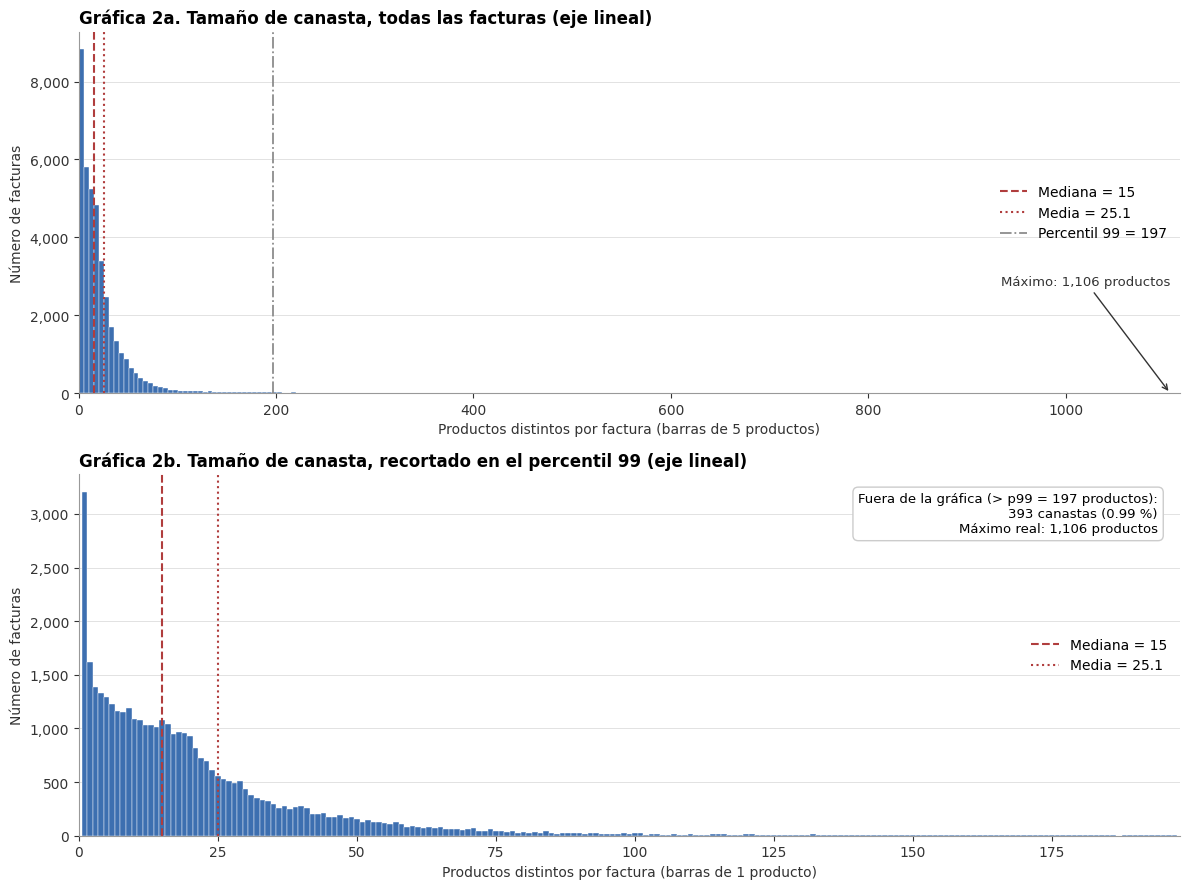

Recorte visual en p99 = 197 productos: quedan fuera 393 canastas (0.99 %); máximo real 1,106
Facturas con más de 200 productos: 380 (0.96 %) | con más de 500: 58 (0.15 %)
Moda del tamaño: 1 productos (3,208 facturas) | facturas de 1 producto: 3,208 (8.12 %)


In [33]:
# Histogramas del tamaño de canasta en eje lineal: 2a con todas las canastas y 2b recortado en el percentil 99
tam = canastas["tamano"]
corte = int(np.ceil(tam.quantile(0.99)))
fuera = tam > corte

fig, axes = plt.subplots(2, 1, figsize=(12, 9))
ax = axes[0]
ax.hist(tam, bins=np.arange(0.5, tam.max() + 5.5, 5), color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(tam.median(), color=ROJO, linestyle="--", linewidth=1.5, label=f"Mediana = {tam.median():.0f}")
ax.axvline(tam.mean(), color=ROJO, linestyle=":", linewidth=1.5, label=f"Media = {tam.mean():.1f}")
ax.axvline(corte, color=GRIS, linestyle="-.", linewidth=1.3, label=f"Percentil 99 = {corte}")
ax.annotate(f"Máximo: {tam.max():,} productos", xy=(tam.max(), 0), xycoords="data", xytext=(tam.max(), 0.3),
            textcoords=("data", "axes fraction"), ha="right", fontsize=9.5, color=TINTA,
            arrowprops=dict(arrowstyle="->", color=TINTA, linewidth=1))
ax.set_xlim(0, tam.max() + 10)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
estilo_ejes(ax, "Gráfica 2a. Tamaño de canasta, todas las facturas (eje lineal)",
            "Productos distintos por factura (barras de 5 productos)", "Número de facturas")
ax.legend(loc="center right")

ax = axes[1]
ax.hist(tam[~fuera], bins=np.arange(0.5, corte + 1.5, 1), color=AZUL, edgecolor="white", linewidth=0.3)
ax.axvline(tam.median(), color=ROJO, linestyle="--", linewidth=1.5, label=f"Mediana = {tam.median():.0f}")
ax.axvline(tam.mean(), color=ROJO, linestyle=":", linewidth=1.5, label=f"Media = {tam.mean():.1f}")
ax.text(0.98, 0.95, f"Fuera de la gráfica (> p99 = {corte} productos):\n{fuera.sum():,} canastas ({pct(fuera.mean())})\n"
        f"Máximo real: {tam.max():,} productos", transform=ax.transAxes, ha="right", va="top", fontsize=9.5,
        bbox=dict(facecolor="white", edgecolor="#CCCCCC", boxstyle="round,pad=0.4"))
ax.set_xlim(0, corte + 1)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
estilo_ejes(ax, "Gráfica 2b. Tamaño de canasta, recortado en el percentil 99 (eje lineal)",
            "Productos distintos por factura (barras de 1 producto)", "Número de facturas")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

print(f"Recorte visual en p99 = {corte} productos: quedan fuera {fuera.sum():,} canastas ({pct(fuera.mean())}); "
      f"máximo real {tam.max():,}")
print(f"Facturas con más de 200 productos: {(tam > 200).sum():,} ({pct((tam > 200).mean())}) | "
      f"con más de 500: {(tam > 500).sum():,} ({pct((tam > 500).mean())})")
print(f"Moda del tamaño: {tam.mode().iat[0]} productos ({(tam == tam.mode().iat[0]).sum():,} facturas) | "
      f"facturas de 1 producto: {(tam == 1).sum():,} ({pct((tam == 1).mean())})")

**Observaciones: transacciones y tamaño de canasta**

- **Codificación.** La matriz one-hot tiene **39,516 × 4,726** celdas, pero solo **992,053 unos**: la **densidad es
  0.005312**, es decir, una factura típica contiene alrededor del 0.5 % del catálogo. La versión dispersa ocupa **5.0 MB**
  y la densa ocuparía **186.8 MB**. El ahorro hace práctico guardar una matriz por trimestre.
- **Etiquetas.** **592** `StockCode` tienen más de una descripción y se etiquetan con la más frecuente. El minado no
  depende de esto, porque trabaja con el código.
- **Asimetría.** El tamaño mediano es **15 productos** y la media **25.1**. La media queda muy por encima de la mediana
  por una cola larga: el percentil 90 es **51**, el 99 es **196.85** y el máximo es **1,106 productos**.
- **Gráfica 2a (completa).** Casi todo el histograma se concentra por debajo de 100 productos, y la cola se extiende,
  casi invisible en escala lineal, hasta el máximo de **1,106**: solo **380** facturas (**0.96 %**) tienen más de 200
  productos y **58** (**0.15 %**) más de 500.
- **Gráfica 2b (recortada en el p99).** Muestra el detalle de la canasta típica. La moda es la canasta de **1 producto**
  (**3,208 facturas, 8.12 %**), y a partir de ahí la frecuencia baja de forma gradual. El recorte deja fuera
  **393 canastas (0.99 %)**. Esa cola casi no se ve en las gráficas, pero importa mucho para el costo del algoritmo, como
  se muestra en la sección 2.1.

**Frecuencia de cada producto = la primera pasada de FP-Growth.** El algoritmo empieza recorriendo una vez todas las
transacciones para contar en cuántas aparece cada ítem, es decir, su soporte $\text{sop}(\{i\}) = \sigma(\{i\})/N$. Con ese
conteo descarta los ítems con soporte menor que $s$: por antimonotonía, ningún conjunto que los contenga puede ser
frecuente. Los ítems que quedan se ordenan de mayor a menor frecuencia para construir el árbol. La curva rango–frecuencia
(Gráfica 3a) muestra justamente ese conteo, con los productos ordenados de más a menos frecuente, en escala lineal.
El histograma (Gráfica 3b) presenta la misma información como distribución: cuántos productos aparecen en un
número dado de facturas. Las líneas rojas marcan el umbral de la pasada 1 para tres soportes mínimos.

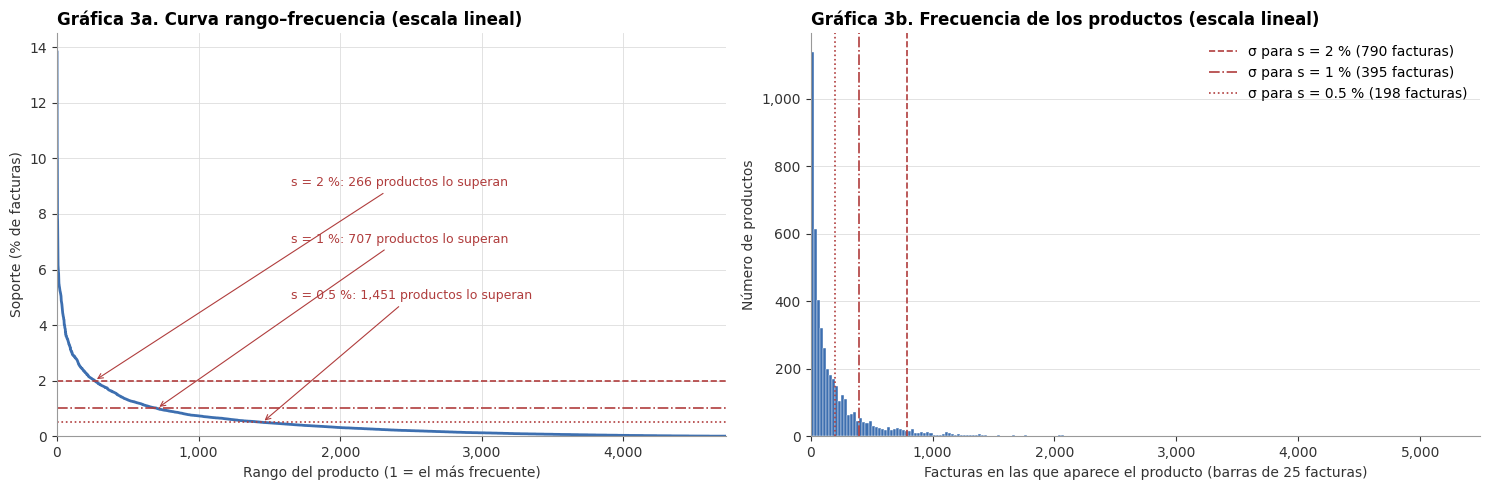

Facturas por producto: media 209.9 | mediana 89 | máximo 5,464
Productos en la primera barra (menos de 25 facturas): 1,139 (24.10 %)
Productos por debajo de σ (los descarta la pasada 1): {'s = 2 % (σ = 790.3)': 4460, 's = 1 % (σ = 395.2)': 4019, 's = 0.5 % (σ = 197.6)': 3275}


,Producto,Soporte (%),Facturas
85123A,WHITE HANGING HEART T-LIGHT HOLDER,13.83,5464
85099B,JUMBO BAG RED RETROSPOT,10.16,4013
22423,REGENCY CAKESTAND 3 TIER,9.91,3918
21212,PACK OF 72 RETROSPOT CAKE CASES,7.89,3118
20725,LUNCH BAG RED RETROSPOT,7.73,3056
84879,ASSORTED COLOUR BIRD ORNAMENT,7.10,2807
47566,PARTY BUNTING,6.77,2674
21232,STRAWBERRY CERAMIC TRINKET BOX,6.16,2435
22383,LUNCH BAG SUKI DESIGN,6.07,2398
20727,LUNCH BAG BLACK SKULL.,5.95,2351


Productos que superan cada soporte mínimo (lo que deja pasar la pasada 1): {'2 %': 266, '1 %': 707, '0.5 %': 1451}
Productos que aparecen en una sola factura: 120 | mediana del soporte: 0.225 %
El 10 % de productos más vendidos (472) concentra el 47.9 % de las apariciones en canastas.


In [34]:
# Primera pasada de FP-Growth: frecuencia de cada producto y curva rango–frecuencia
N_todas = len(X_todas)
soporte_producto = (conteo_columnas(X_todas) / N_todas).sort_values(ascending=False)
rango = np.arange(1, len(soporte_producto) + 1)

UMBRALES_S = [(0.02, "--"), (0.01, "-."), (0.005, ":")]
facturas_producto = (soporte_producto * N_todas).round().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.plot(rango, 100 * soporte_producto.values, color=AZUL, linewidth=2)
for (s, estilo), y_texto in zip(UMBRALES_S, [0.62, 0.48, 0.34]):
    k = int((soporte_producto >= s).sum())
    ax.axhline(100 * s, color=ROJO, linestyle=estilo, linewidth=1.2)
    ax.annotate(f"s = {100 * s:g} %: {k:,} productos lo superan", xy=(k, 100 * s), xytext=(0.35, y_texto),
                textcoords="axes fraction", color=ROJO, fontsize=9,
                arrowprops=dict(arrowstyle="->", color=ROJO, linewidth=0.8))
ax.set_xlim(0, len(rango))
ax.set_ylim(0, None)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
estilo_ejes(ax, "Gráfica 3a. Curva rango–frecuencia (escala lineal)", "Rango del producto (1 = el más frecuente)",
            "Soporte (% de facturas)", rejilla="both")

ax = axes[1]
ax.hist(facturas_producto, bins=np.arange(0, facturas_producto.max() + 25, 25), color=AZUL, edgecolor="white", linewidth=0.3)
for s, estilo in UMBRALES_S:
    ax.axvline(s * N_todas, color=ROJO, linestyle=estilo, linewidth=1.2,
               label=f"σ para s = {100 * s:g} % ({s * N_todas:,.0f} facturas)")
ax.set_xlim(0, facturas_producto.max() + 25)
ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
estilo_ejes(ax, "Gráfica 3b. Frecuencia de los productos (escala lineal)",
            "Facturas en las que aparece el producto (barras de 25 facturas)", "Número de productos")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Facturas por producto: media {facturas_producto.mean():,.1f} | mediana {facturas_producto.median():,.0f} | "
      f"máximo {facturas_producto.max():,}")
print(f"Productos en la primera barra (menos de 25 facturas): {(facturas_producto < 25).sum():,} "
      f"({pct((facturas_producto < 25).mean())})")
print("Productos por debajo de σ (los descarta la pasada 1):",
      {f"s = {100 * s:g} % (σ = {s * N_todas:,.1f})": int((soporte_producto < s).sum()) for s, _ in UMBRALES_S})

top = soporte_producto.head(10).rename("Soporte (%)").mul(100).round(2).to_frame()
top.insert(0, "Producto", etiquetas.reindex(top.index).values)
top["Facturas"] = (soporte_producto[top.index] * N_todas).round().astype(int).values
display(top)
print("Productos que superan cada soporte mínimo (lo que deja pasar la pasada 1):",
      {f"{100 * s:g} %": int((soporte_producto >= s).sum()) for s in [0.02, 0.01, 0.005]})
print(f"Productos que aparecen en una sola factura: {(soporte_producto * N_todas < 1.5).sum():,} | "
      f"mediana del soporte: {pct(soporte_producto.median(), 3)}")
cum = soporte_producto.cumsum() / soporte_producto.sum()
print(f"El 10 % de productos más vendidos ({int(len(cum) * 0.1):,}) concentra el {pct(cum.iloc[int(len(cum) * 0.1) - 1], 1)} de las apariciones en canastas.")

**Observaciones: frecuencia de los productos (pasada 1)**

- **Gráfica 3a.** En escala lineal la curva tiene forma de "L": una cabeza corta de productos muy vendidos y una cola
  larga casi plana. El más frecuente, `WHITE HANGING HEART T-LIGHT HOLDER`, está en el **13.83 %** de las facturas
  (**5,464**). La mediana del soporte es apenas **0.225 %**.
- **Gráfica 3b.** El histograma muestra la misma asimetría:
  - un producto aparece en promedio en **209.9** facturas, pero la mediana es **89**;
  - **1,139** productos (**24.10 %**) aparecen en menos de 25 facturas (la primera barra), y **120** en una sola.
- **Concentración.** El 10 % de productos más vendidos (**472**) concentra el **47.9 %** de las apariciones en canastas.
- **Lo que deja pasar la pasada 1:** con $s$ = 2 % sobreviven **266 productos**; con 1 %, **707**; con 0.5 %, **1,451**.
  Es decir, el FP-tree se construye sobre entre el 6 % y el 31 % del catálogo, y cada vez que $s$ se reduce a la mitad,
  el universo de ítems frecuentes más que se duplica. En la Gráfica 3b, todo lo que queda a la izquierda de cada línea
  roja se descarta: **3,275**, **4,019** y **4,460** productos con $s$ = 0.5 %, 1 % y 2 %.
- **Top 10.** Lo forman productos de decoración y bolsas (`JUMBO BAG RED RETROSPOT` **10.16 %**, `REGENCY CAKESTAND 3 TIER`
  **9.91 %**, tres modelos de `LUNCH BAG`). Esos productos van a dominar los itemsets frecuentes.

### 2.1 Hallazgo de calidad: las facturas sin `Customer ID`

Al probar FP-Growth por trimestre apareció un problema: en algunos trimestres, bajar un poco el soporte mínimo hacía que
el número de itemsets pasara de miles a millones, y el algoritmo no terminaba. Antes de decidir qué hacer, esta
subsección **caracteriza las facturas sin `Customer ID`**, que resultaron ser la causa:

1. **Tamaño:** se comparan sus canastas con las de las facturas con cliente. Se llama **gigante** a una factura con más
   productos que el percentil 99 de las facturas *con* cliente.
2. **Cuándo y dónde** ocurren (por mes y por país).
3. **Qué tan parecidas son entre sí**, con la similitud de Jaccard $J(A,B) = |A \cap B| / |A \cup B|$.
4. **Prueba de que causan la explosión:** se cuentan los itemsets frecuentes de un trimestre con y sin ellas.

In [35]:
# Tamaño de canasta con y sin Customer ID; facturas "gigantes"
canastas["con_cliente"] = canastas["cliente"].notna()
UMBRAL_GIGANTE = int(canastas.loc[canastas["con_cliente"], "tamano"].quantile(0.99))
canastas["gigante"] = canastas["tamano"] > UMBRAL_GIGANTE
grupo = canastas["con_cliente"].map({True: "Con Customer ID", False: "Sin Customer ID"})

tabla_tam = (canastas.groupby(grupo)["tamano"]
             .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(1))
tabla_tam["gigantes (> p99 con cliente)"] = canastas.groupby(grupo)["gigante"].sum()
tabla_tam["% gigantes"] = (100 * canastas.groupby(grupo)["gigante"].mean()).round(2)
tabla_tam["% de las facturas"] = (100 * tabla_tam["count"] / len(canastas)).round(2)
tabla_tam["% de los pares (factura, producto)"] = (100 * canastas.groupby(grupo)["tamano"].sum() / canastas["tamano"].sum()).round(2)
display(tabla_tam)
print(f"Umbral de canasta gigante = percentil 99 de las facturas con cliente = {UMBRAL_GIGANTE} productos")
gig = canastas["gigante"]
print(f"Facturas gigantes: {gig.sum():,}, de las cuales {(gig & ~canastas['con_cliente']).sum():,} "
      f"({pct((gig & ~canastas['con_cliente']).sum() / gig.sum(), 1)}) no tienen Customer ID")

,count,mean,std,min,25%,50%,75%,90%,99%,max,gigantes (> p99 con cliente),% gigantes,% de las facturas,"% de los pares (factura, producto)"
con_cliente,,,,,,,,,,,,,,
Con Customer ID,36594.0,20.9,22.4,1.0,7.0,15.0,27.0,46.0,101.0,540.0,365,1.00,92.61,77.22
Sin Customer ID,2922.0,77.3,122.2,1.0,3.0,19.5,120.0,218.9,565.5,1106.0,787,26.93,7.39,22.78


Umbral de canasta gigante = percentil 99 de las facturas con cliente = 101 productos
Facturas gigantes: 1,152, de las cuales 787 (68.3 %) no tienen Customer ID


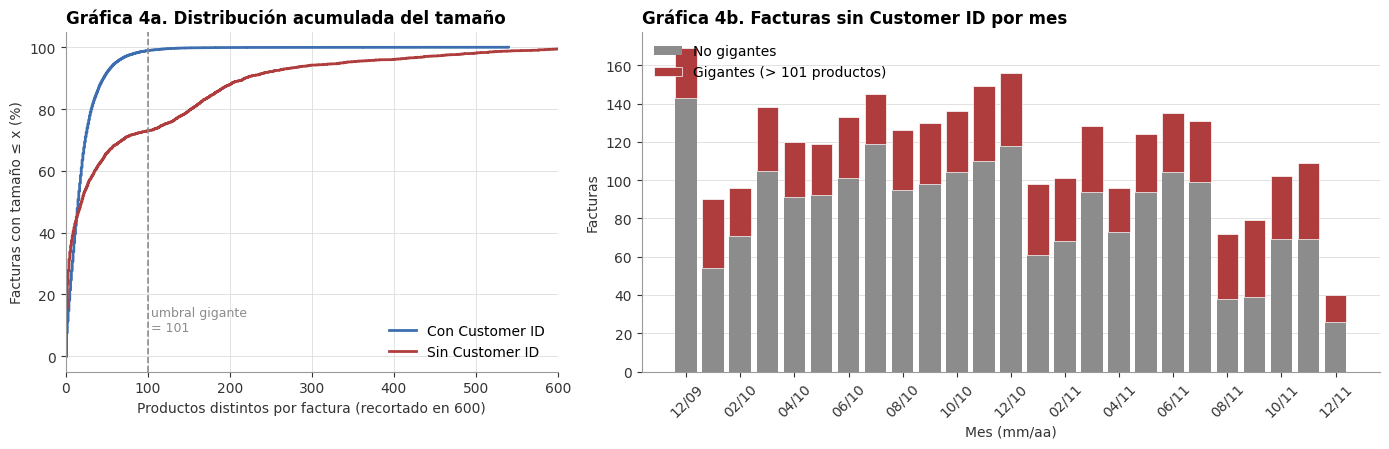

Países de las facturas sin Customer ID:


,todas,gigantes
pais,,
United Kingdom,2823,787
EIRE,53,0
Hong Kong,9,0
France,8,0
Unspecified,8,0
Bahrain,6,0


Meses con más facturas gigantes sin cliente: {'09/2011': 40, '11/2011': 40, '11/2010': 39, '12/2010': 38}
Día de la semana de las gigantes sin cliente: {'Monday': 198, 'Tuesday': 191, 'Wednesday': 147, 'Friday': 136, 'Thursday': 112, 'Sunday': 3}


In [36]:
# ¿Cuándo y dónde ocurren las facturas sin Customer ID?
sin = canastas[~canastas["con_cliente"]]
mes = sin["fecha"].dt.to_period("M")
por_mes = pd.crosstab(mes, sin["gigante"]).reindex(pd.period_range(canastas["fecha"].min(), canastas["fecha"].max(), freq="M"),
                                                fill_value=0)
por_mes.columns = ["No gigantes", "Gigantes"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})
ax = axes[0]
for nombre_g, color in [("Con Customer ID", AZUL), ("Sin Customer ID", ROJO)]:
    t = np.sort(canastas.loc[grupo == nombre_g, "tamano"].values)
    ax.step(t, np.arange(1, len(t) + 1) / len(t) * 100, where="post", color=color, linewidth=2, label=nombre_g)
ax.axvline(UMBRAL_GIGANTE, color=GRIS, linestyle="--", linewidth=1.2)
ax.text(UMBRAL_GIGANTE * 1.03, 8, f"umbral gigante\n= {UMBRAL_GIGANTE}", color=GRIS, fontsize=9)
ax.set_xlim(0, 600)
estilo_ejes(ax, "Gráfica 4a. Distribución acumulada del tamaño", "Productos distintos por factura (recortado en 600)",
            "Facturas con tamaño ≤ x (%)", rejilla="both")
ax.legend(loc="lower right")

ax = axes[1]
xm = np.arange(len(por_mes))
ax.bar(xm, por_mes["No gigantes"], color=GRIS, width=0.8, label="No gigantes")
ax.bar(xm, por_mes["Gigantes"], bottom=por_mes["No gigantes"], color=ROJO, width=0.8, label=f"Gigantes (> {UMBRAL_GIGANTE} productos)",
       edgecolor="white", linewidth=0.5)
ax.set_xticks(xm[::2], [p.strftime("%m/%y") for p in por_mes.index[::2]], rotation=45)
estilo_ejes(ax, "Gráfica 4b. Facturas sin Customer ID por mes", "Mes (mm/aa)", "Facturas")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("Países de las facturas sin Customer ID:")
paises = pd.DataFrame({"todas": sin["pais"].value_counts(), "gigantes": sin.loc[sin["gigante"], "pais"].value_counts()}).fillna(0).astype(int)
display(paises.sort_values("todas", ascending=False).head(6))
print(f"Meses con más facturas gigantes sin cliente: {por_mes['Gigantes'].nlargest(4).rename(lambda p: p.strftime("%m/%Y")).to_dict()}")
dias = sin.loc[sin["gigante"], "fecha"].dt.day_name().value_counts()
print(f"Día de la semana de las gigantes sin cliente: {dias.to_dict()}")

**Por qué importa la similitud.** Para FP-Growth no basta con que una canasta sea grande: importa que **muchas canastas
grandes compartan casi los mismos productos**. Si $m$ facturas comparten un bloque de $k$ productos y $m \ge \sigma$,
entonces los $2^k - 1$ subconjuntos de ese bloque son frecuentes. Con $k = 18$ eso ya son más de 260 mil itemsets, y no por
un patrón de consumo, sino por la repetición del mismo pedido.

Para cada factura gigante se calcula el Jaccard con la factura **más parecida de su grupo** (su vecina). Se comparan las
gigantes sin cliente con una muestra del mismo tamaño de gigantes con cliente.

,facturas,clientes distintos,Jaccard mediano entre parejas,Jaccard mediano con la vecina más parecida,% con vecina J ≥ 0.5,productos compartidos con la vecina (mediana),% que comparte ≥ 30 productos con otra,productos en ≥ 50 % de las facturas
grupo,,,,,,,,
Gigantes sin Customer ID,365,0,0.073,0.177,2.466,110.0,100.000,10
Gigantes con Customer ID,365,200,0.041,0.141,0.548,45.0,91.781,0


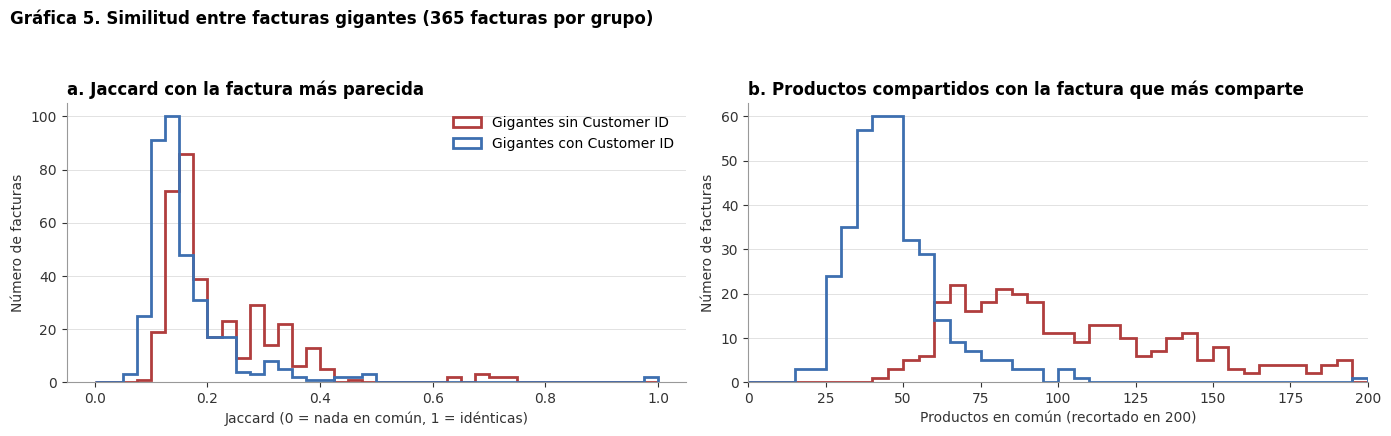

In [37]:
# Similitud entre facturas gigantes: Jaccard de cada factura con su vecina más parecida
def matriz_jaccard(items):
    """
    Calcula la similitud de Jaccard entre todas las parejas de canastas.

    Parámetros
    ----------
    items : list of frozenset
        Canastas a comparar.

    Retorna
    -------
    tuple of np.ndarray
        Matriz n × n de Jaccard J(a, b) = |a ∩ b| / |a ∪ b| con NaN en la diagonal, y matriz n × n de productos
        compartidos |a ∩ b| con 0 en la diagonal.
    """
    m = codificar(items).sparse.to_coo().tocsr().astype(np.int32)
    inter = (m @ m.T).toarray()
    tam_c = np.asarray(m.sum(axis=1)).ravel()
    jac = inter / (tam_c[:, None] + tam_c[None, :] - inter)
    np.fill_diagonal(jac, np.nan)
    np.fill_diagonal(inter, 0)
    return jac, inter


gig_sin = canastas[canastas["gigante"] & ~canastas["con_cliente"]]
gig_con = canastas[canastas["gigante"] & canastas["con_cliente"]]
n_comp = min(len(gig_sin), len(gig_con))
grupos_j = {"Gigantes sin Customer ID": gig_sin.sample(n_comp, random_state=42),
            "Gigantes con Customer ID": gig_con.sample(n_comp, random_state=42)}

filas, vecina, compartidos = [], {}, {}
for nombre_g, g in grupos_j.items():
    jac, inter = matriz_jaccard(g["items"].tolist())
    vecina[nombre_g] = np.nanmax(jac, axis=1)
    compartidos[nombre_g] = inter.max(axis=1)
    conteo = pd.Series([p for s in g["items"] for p in s]).value_counts()
    filas.append({"grupo": nombre_g, "facturas": len(g), "clientes distintos": g["cliente"].nunique(),
                  "Jaccard mediano entre parejas": np.nanmedian(jac),
                  "Jaccard mediano con la vecina más parecida": np.median(vecina[nombre_g]),
                  "% con vecina J ≥ 0.5": 100 * (vecina[nombre_g] >= 0.5).mean(),
                  "productos compartidos con la vecina (mediana)": np.median(compartidos[nombre_g]),
                  "% que comparte ≥ 30 productos con otra": 100 * (compartidos[nombre_g] >= 30).mean(),
                  "productos en ≥ 50 % de las facturas": int((conteo >= 0.5 * len(g)).sum())})
display(pd.DataFrame(filas).set_index("grupo").round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for nombre_g, color in zip(grupos_j, [ROJO, AZUL]):
    axes[0].hist(vecina[nombre_g], bins=np.linspace(0, 1, 41), histtype="step", linewidth=2, color=color, label=nombre_g)
    axes[1].hist(compartidos[nombre_g], bins=np.arange(0, 205, 5), histtype="step", linewidth=2, color=color, label=nombre_g)
estilo_ejes(axes[0], "a. Jaccard con la factura más parecida", "Jaccard (0 = nada en común, 1 = idénticas)",
            "Número de facturas")
estilo_ejes(axes[1], "b. Productos compartidos con la factura que más comparte", "Productos en común (recortado en 200)",
            "Número de facturas")
axes[1].set_xlim(0, 200)
axes[0].legend()
fig.suptitle(f"Gráfica 5. Similitud entre facturas gigantes ({n_comp} facturas por grupo)", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

**Prueba de la explosión.** En el trimestre 1T-2011 se ejecuta FP-Growth con soportes decrecientes, primero con todas las
facturas y después solo con las que tienen cliente. Para que la prueba siempre termine, `fpgrowth_con_tope()` sube
`max_len` de uno en uno y se detiene si se superan 300 mil itemsets. En ese caso el número reportado es una **cota
inferior** (punto hueco en la gráfica). Que una corrida "complete" significa que, a esa longitud, ya no aparecen itemsets
más largos.

σ = s·N                        itemsets (texto)                                  longitud                              tiempo (s)                   
versión Solo con Customer ID Todas las facturas Solo con Customer ID   Todas las facturas Solo con Customer ID Todas las facturas Solo con Customer ID Todas las facturas
s                                                                                                                                                                        
0.0100                 32.87              36.14                1,368                2,921                    5                  5             2.039425           4.551916
0.0090                29.583             32.526                1,662                4,013                    6                  6             2.430604           5.996688
0.0080                26.296             28.912                2,088                6,135                    6                  6             3.058075           7.071553
0.0075               24.6525             27.105                2,471                7,090                    6                  6             2.749578           7.919888
0.0070                23.009             25.298                2,713              291,886                    6                 18             2.815197          36.741028
0.0065               21.3655             23.491                3,284  ≥ 611,927 (cortado)                    6                  5             3.431605          10.160664

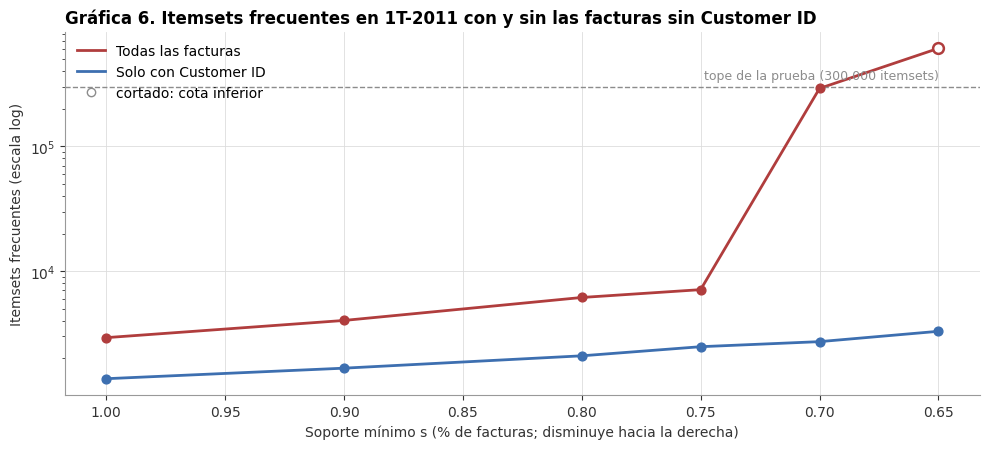

s = 0.007: 291,886 itemsets; 108,235 de longitud ≥ 10 (37.08 %).
Itemset más largo: 18 productos. Lo contienen 26 facturas: 26 sin Customer ID, del 04/01/2011 al 21/01/2011, países ['United Kingdom'], tamaños 88–501 productos.
Productos presentes en esas 26 facturas a la vez: 18 -> 2^18 - 1 = 262,143 subconjuntos con al menos 26 facturas (σ mínimo = 26).
Ejemplos de productos del núcleo: BLUE ROSE FABRIC MIRROR, CHRISTMAS TREE DECORATION WITH BELL, COLOURING PENCILS BROWN TUBE, LARGE CAKE TOWEL PINK SPOTS, ROTATING LEAVES T-LIGHT HOLDER, STRAWBERRY SHOPPER BAG


In [38]:
# Prueba de la explosión: itemsets en 1T-2011 con y sin las facturas sin Customer ID
def fpgrowth_con_tope(X, s, tope=300_000, max_len_max=40):
    """
    Ejecuta FP-Growth subiendo max_len de uno en uno y se detiene si los itemsets superan un tope.

    Sirve para medir una explosión combinatoria sin quedarse sin memoria ni tiempo: si se alcanza el tope,
    el resultado es una cota inferior del número real de itemsets.

    Parámetros
    ----------
    X : pd.DataFrame
        Matriz one-hot (densa o dispersa).
    s : float
        Soporte mínimo relativo.
    tope : int
        Máximo de itemsets tolerado antes de cortar.
    max_len_max : int
        Longitud máxima que se llega a probar.

    Retorna
    -------
    dict
        itemsets (int), longitud alcanzada (int), completo (bool) y tiempo acumulado en segundos.
    """
    t0 = time.perf_counter()
    for k in range(2, max_len_max + 1):
        fi = fpgrowth(X, min_support=s, max_len=k)
        n, lmax = len(fi), int(fi["itemsets"].map(len).max()) if len(fi) else 0
        if n > tope:
            return {"itemsets": n, "longitud": k, "completo": False, "tiempo (s)": time.perf_counter() - t0}
        if lmax < k:
            return {"itemsets": n, "longitud": lmax, "completo": True, "tiempo (s)": time.perf_counter() - t0}
    return {"itemsets": n, "longitud": lmax, "completo": False, "tiempo (s)": time.perf_counter() - t0}


TRIM_PRUEBA = "1T-2011"
GRID_PRUEBA = [0.01, 0.009, 0.008, 0.0075, 0.007, 0.0065]
TOPE = 300_000
prueba = canastas[canastas["trimestre"] == TRIM_PRUEBA]
versiones = {"Todas las facturas": prueba, "Solo con Customer ID": prueba[prueba["con_cliente"]]}
filas = []
for nombre_v, sub in versiones.items():
    Xv = codificar(sub["items"].tolist())
    for s in GRID_PRUEBA:
        r = fpgrowth_con_tope(Xv, s, tope=TOPE)
        filas.append({"versión": nombre_v, "N": len(sub), "s": s, "σ = s·N": s * len(sub), **r})
explosion = pd.DataFrame(filas)
explosion["itemsets (texto)"] = np.where(explosion["completo"], explosion["itemsets"].map("{:,}".format),
                                         "≥ " + explosion["itemsets"].map("{:,}".format) + " (cortado)")
display(explosion.pivot(index="s", columns="versión", values=["σ = s·N", "itemsets (texto)", "longitud", "tiempo (s)"])
        .sort_index(ascending=False).round(2))

fig, ax = plt.subplots(figsize=(10, 4.6))
for (nombre_v, d), color in zip(explosion.groupby("versión", sort=False), [ROJO, AZUL]):
    ax.plot(100 * d["s"], d["itemsets"], color=color, linewidth=2, label=nombre_v)
    ax.scatter(100 * d.loc[d["completo"], "s"], d.loc[d["completo"], "itemsets"], color=color, s=40, zorder=3)
    ax.scatter(100 * d.loc[~d["completo"], "s"], d.loc[~d["completo"], "itemsets"], facecolor="white", edgecolor=color,
               s=60, linewidth=1.8, zorder=3)
ax.axhline(TOPE, color=GRIS, linestyle="--", linewidth=1)
ax.text(100 * GRID_PRUEBA[-1], TOPE * 1.15, f"tope de la prueba ({TOPE:,} itemsets)", color=GRIS, fontsize=9, ha="right")
ax.set_yscale("log")
ax.invert_xaxis()
ax.legend(handles=ax.get_legend_handles_labels()[0] + [Line2D([], [], marker="o", color=GRIS, markerfacecolor="white",
          linestyle="none", label="cortado: cota inferior")], loc="upper left")
estilo_ejes(ax, f"Gráfica 6. Itemsets frecuentes en {TRIM_PRUEBA} con y sin las facturas sin Customer ID",
            "Soporte mínimo s (% de facturas; disminuye hacia la derecha)", "Itemsets frecuentes (escala log)", rejilla="both")
plt.tight_layout()
plt.show()

# ¿Qué facturas producen los itemsets largos? Se repite la corrida con todas las facturas a s = 0.7 % (sí termina)
S_EXPLOSION = 0.007
fi_exp = fpgrowth(codificar(prueba["items"].tolist()), min_support=S_EXPLOSION, use_colnames=True)
largo_exp = fi_exp["itemsets"].map(len)
mas_largo = fi_exp.loc[largo_exp.idxmax(), "itemsets"]
contienen = prueba[prueba["items"].map(mas_largo.issubset)]
nucleo = frozenset.intersection(*contienen["items"])
print(f"s = {S_EXPLOSION}: {len(fi_exp):,} itemsets; {(largo_exp >= 10).sum():,} de longitud ≥ 10 ({pct((largo_exp >= 10).mean())}).")
print(f"Itemset más largo: {len(mas_largo)} productos. Lo contienen {len(contienen)} facturas: "
      f"{(~contienen['con_cliente']).sum()} sin Customer ID, del {contienen['fecha'].min():%d/%m/%Y} al {contienen['fecha'].max():%d/%m/%Y}, "
      f"países {contienen['pais'].unique().tolist()}, tamaños {contienen['tamano'].min()}–{contienen['tamano'].max()} productos.")
print(f"Productos presentes en esas {len(contienen)} facturas a la vez: {len(nucleo)} -> 2^{len(nucleo)} - 1 = {2 ** len(nucleo) - 1:,} "
      f"subconjuntos con al menos {len(contienen)} facturas (σ mínimo = {int(np.ceil(S_EXPLOSION * len(prueba)))}).")
print("Ejemplos de productos del núcleo:", ", ".join(sorted(etiquetas.reindex(sorted(nucleo)).head(6))))

**Observaciones: facturas sin `Customer ID` (hallazgo)**

- **Son mucho más grandes.**
  - Las **2,922** facturas sin cliente son el **7.39 %** de las facturas, pero aportan el **22.78 %** de los pares
    (factura, producto).
  - Su tamaño medio es **77.3** productos contra **20.9** de las facturas con cliente, y su p90 es **218.9** contra **46**.
  - Con el umbral de gigante (más de **101 productos**, el p99 de las facturas con cliente), **787** facturas sin cliente
    son gigantes (**26.93 %**), contra el **1.00 %** de las facturas con cliente.
  - De las **1,152** facturas gigantes, el **68.3 %** no tiene cliente.
  - La Gráfica 4a lo muestra: la curva acumulada de las facturas sin cliente se separa a partir de unos 25 productos y
    llega al 100 % mucho más tarde.
- **Cuándo y dónde.**
  - Las **787** gigantes sin cliente son **todas de Reino Unido**. En total, **2,823** de las 2,922 facturas sin cliente
    son de ese país.
  - No se concentran en una temporada: aparecen todos los meses (Gráfica 4b), con un máximo de **40** por mes en 09/2011
    y 11/2011.
  - Ocurren en días hábiles (lunes **198**, martes **191**) y casi nunca en domingo (**3**).
  - El patrón (pedidos de cientos de productos distintos, en días laborales y sin cliente registrado) es más compatible
    con **reposición interna o ventas por canales sin registro de cliente** que con compradores individuales. El dataset
    no permite confirmarlo.
- **Qué tan parecidas son (Gráfica 5).** Se compararon **365** gigantes de cada grupo:
  - El Jaccard de canasta completa apenas las distingue: la mediana con la vecina más parecida es **0.177** sin cliente
    y **0.141** con cliente. Con cientos de productos por factura, la unión es tan grande que diluye la similitud.
  - Lo decisivo es **cuántos productos comparten**. La mediana de productos en común con la vecina es **110** sin cliente
    y **45** con cliente.
  - **10** productos están en al menos la mitad de las gigantes sin cliente; entre las gigantes con cliente, **ninguno**.
  - En otras palabras, las facturas sin cliente comparten un **núcleo** de productos.
- **Prueba de la explosión (Gráfica 6, 1T-2011).**
  - **Solo con cliente**, los itemsets crecen de forma moderada: de **1,368** con $s$ = 1 % a **3,284** con $s$ = 0.65 %,
    con longitud máxima de 5 a 6.
  - **Con todas las facturas** hay más itemsets desde el principio (**2,921** con $s$ = 1 %) y, al pasar de $s$ = 0.75 %
    (**7,090**) a $s$ = 0.7 %, el conteo salta a **291,886** itemsets, con longitud máxima **18**. **108,235** de ellos
    (**37.08 %**) tienen longitud ≥ 10.
  - Con $s$ = 0.65 % la prueba se corta al pasar el tope: **≥ 611,927** itemsets, ya con longitud 5.
- **Las responsables.** El itemset más largo (**18 productos**) está en **26 facturas, las 26 sin `Customer ID`**, de Reino
  Unido, emitidas entre el **04/01/2011** y el **21/01/2011**, con **88 a 501 productos** cada una. Comparten exactamente esos
  **18 productos**. Como 26 coincide con $\sigma_{\min} = \lceil 0.007 \cdot 3{,}614 \rceil = 26$, en cuanto $s$ baja a
  0.7 % los **$2^{18}-1$ = 262,143** subconjuntos del núcleo se vuelven frecuentes a la vez. Eso explica casi todos los
  291,886 itemsets. Este puede ser un mismo pedido repetido a lo largo de este tiempo. 

In [39]:
# Decisión: el minado usa solo las facturas con Customer ID
canastas_cc = canastas[canastas["con_cliente"]].copy()
X_cc = codificar(canastas_cc["items"].tolist())
comparacion = pd.DataFrame({
    "Todas las facturas": est_todas,
    "Solo con Customer ID": estadisticas_canastas(canastas_cc["tamano"], X_cc.shape[1]),
})
comparacion["Cambio (%)"] = 100 * (comparacion["Solo con Customer ID"] / comparacion["Todas las facturas"] - 1)
display(comparacion.map(lambda v: f"{v:,.6f}" if abs(v) < 1 else f"{v:,.2f}"))
print(f"Facturas excluidas: {len(canastas) - len(canastas_cc):,} ({pct(1 - len(canastas_cc) / len(canastas))}) | "
      f"productos que solo aparecían en ellas: {X_todas.shape[1] - X_cc.shape[1]:,}")

,Todas las facturas,Solo con Customer ID,Cambio (%)
Transacciones (N),"39,516.00","36,594.00",-7.39
Productos distintos (d),"4,726.00","4,621.00",-2.22
Tamaño medio,25.11,20.94,-16.61
Desviación estándar,42.26,22.40,-46.99
Mínimo,1.00,1.00,0.000000
Percentil 25,6.00,7.00,16.67
Mediana,15.00,15.00,0.000000
Percentil 75,28.00,27.00,-3.57
Percentil 90,51.00,46.00,-9.80
Percentil 99,196.85,101.00,-48.69


Facturas excluidas: 2,922 (7.39 %) | productos que solo aparecían en ellas: 105


**Observaciones y decisión: conjunto de transacciones final**

**Decisión:** el minado (secciones 3 a 8) usa **solo las facturas con `Customer ID`**. Las razones son tres:

1. Producen una explosión combinatoria que inflaría artificialmente los itemsets largos, no por un patrón de consumo.
2. Sin cliente no se puede revisar si una regla viene de muchos compradores o de unos pocos, que es una de las pruebas de
   la sección 8.

**Efecto en el conjunto:**
- Se pierden **2,922 facturas (7.39 %)** y **105 productos** que solo aparecían en ellas: $N$ pasa de **39,516** a
  **36,594** y $d$ de **4,726** a **4,621**.
- El tamaño medio baja de **25.11** a **20.94**, la mediana se queda en **15**, el p99 baja de **196.85** a **101** y el
  máximo de **1,106** a **540**.
- La densidad baja de **0.005312** a **0.004530**.

Es decir, se elimina la cola de canastas gigantes sin tocar la canasta típica.

**Limitación:** si una parte de esas facturas sí fueran compras reales de clientes no registrados, sus patrones quedan fuera
del análisis.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · PARTICIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Separación por trimestre</span></div>


Se separan las canastas por **trimestre**, según la fecha de la factura (`InvoiceDate`), y se mina cada uno por separado.
Así se puede comparar si una regla aparece todo el año o solo en una temporada. Cada trimestre es su propia base de
transacciones, con su propio $N_q$, y el soporte relativo de un itemset se calcula dentro de su trimestre.

**Trimestres incompletos.** La ventana de datos va del 01/12/2009 al 09/12/2011, así que dos trimestres no están
completos:

- **4T-2009 solo tiene diciembre.** Es un único mes, y además es el de mayor temporada navideña, así que no representa el
  trimestre. **Se excluye del análisis principal** (barrido, minado y comparación). Se muestra en la tabla solo como
  referencia.
- **4T-2011 termina el 9 de diciembre:** tiene octubre y noviembre completos, pero le faltan 22 días de diciembre. Se
  **conserva**, porque contiene la temporada fuerte de pedidos navideños de los mayoristas, pero marcado como incompleto.
  Sus conteos absolutos no son comparables con los del 4T-2010. Su soporte relativo sí lo es, con la salvedad de que la
  mezcla de productos de diciembre está subrepresentada.

,Facturas (todas),Facturas con cliente,Productos distintos,Tamaño medio,Tamaño mediano,Primera fecha,Última fecha,Días con ventas,Completo,En el análisis
trimestre,,,,,,,,,,
4T-2009,1666,1497,2719,19.89,14.0,01/12/2009,23/12/2009,21,False,False
1T-2010,3885,3561,3091,21.07,16.0,04/01/2010,31/03/2010,75,True,True
2T-2010,4531,4159,2968,20.29,15.0,01/04/2010,30/06/2010,73,True,True
3T-2010,4698,4297,3030,19.87,15.0,01/07/2010,30/09/2010,78,True,True
4T-2010,6513,6072,3080,21.47,16.0,01/10/2010,23/12/2010,72,True,True
1T-2011,3614,3287,2624,20.26,15.0,04/01/2011,31/03/2011,75,True,True
2T-2011,4428,4073,2862,18.80,14.0,01/04/2011,30/06/2011,72,True,True
3T-2011,4609,4327,2877,21.23,16.0,01/07/2011,30/09/2011,78,True,True
4T-2011,5572,5321,2922,23.70,16.0,02/10/2011,09/12/2011,60,False,True


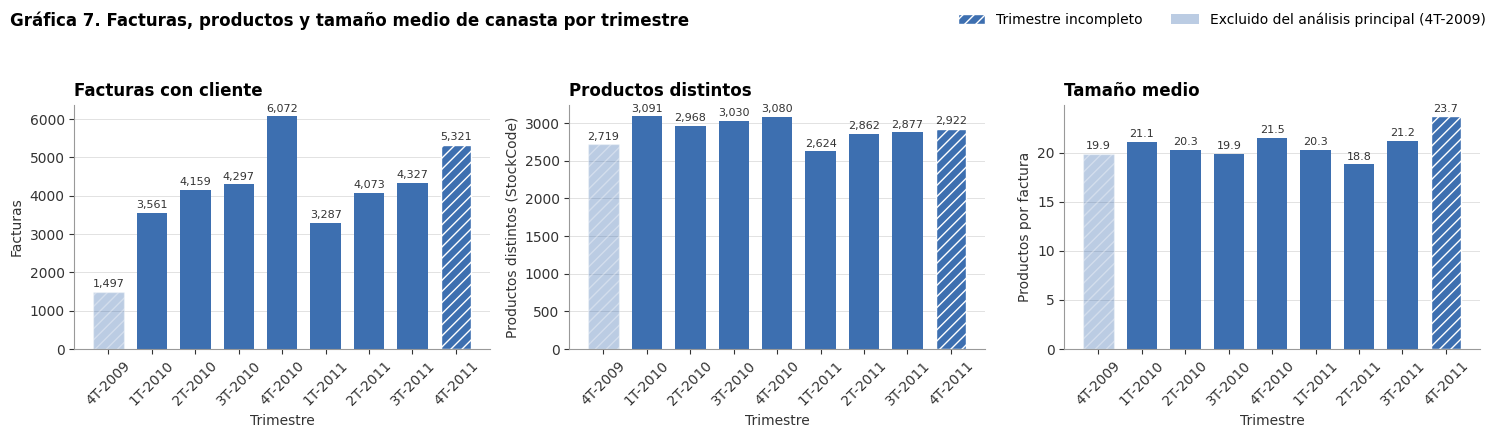

Trimestres del análisis principal: 1T-2010 (N = 3,561), 2T-2010 (N = 4,159), 3T-2010 (N = 4,297), 4T-2010 (N = 6,072), 1T-2011 (N = 3,287), 2T-2011 (N = 4,073), 3T-2011 (N = 4,327), 4T-2011 (N = 5,321)


In [40]:
# Resumen por trimestre (facturas con Customer ID)
ORDEN_TRIM = [f"{p.quarter}T-{p.year}" for p in pd.period_range(INICIO_DATOS, FIN_DATOS, freq="Q")]
COMPLETO = {f"{p.quarter}T-{p.year}": trimestre_completo(p) for p in pd.period_range(INICIO_DATOS, FIN_DATOS, freq="Q")}
TRIM_EXCLUIDOS = ["4T-2009"]
TRIM_ANALISIS = [q for q in ORDEN_TRIM if q not in TRIM_EXCLUIDOS]

g = canastas_cc.groupby("trimestre")
resumen_trim = pd.DataFrame({
    "Facturas (todas)": canastas.groupby("trimestre").size(),
    "Facturas con cliente": g.size(),
    "Productos distintos": g["items"].agg(lambda s: len(frozenset().union(*s))),
    "Tamaño medio": g["tamano"].mean().round(2),
    "Tamaño mediano": g["tamano"].median(),
    "Primera fecha": g["fecha"].min().dt.strftime("%d/%m/%Y"),
    "Última fecha": g["fecha"].max().dt.strftime("%d/%m/%Y"),
    "Días con ventas": g["fecha"].agg(lambda f: f.dt.date.nunique()),
}).reindex(ORDEN_TRIM)
resumen_trim["Completo"] = [COMPLETO[q] for q in ORDEN_TRIM]
resumen_trim["En el análisis"] = [q in TRIM_ANALISIS for q in ORDEN_TRIM]
display(resumen_trim)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, col, ylab in zip(axes, ["Facturas con cliente", "Productos distintos", "Tamaño medio"],
                         ["Facturas", "Productos distintos (StockCode)", "Productos por factura"]):
    barras = ax.bar(ORDEN_TRIM, resumen_trim[col], color=AZUL, width=0.7)
    for b, q in zip(barras, ORDEN_TRIM):
        if not COMPLETO[q]:
            b.set_hatch("///")
            b.set_edgecolor("white")
        if q in TRIM_EXCLUIDOS:
            b.set_alpha(0.35)
    ax.bar_label(barras, labels=[f"{v:,.0f}" if col != "Tamaño medio" else f"{v:.1f}" for v in resumen_trim[col]],
                 fontsize=8, padding=2, color=TINTA)
    ax.tick_params(axis="x", rotation=45)
    estilo_ejes(ax, col, "Trimestre", ylab)
fig.suptitle("Gráfica 7. Facturas, productos y tamaño medio de canasta por trimestre", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
fig.legend(handles=[Patch(facecolor=AZUL, hatch="///", edgecolor="white", label="Trimestre incompleto"),
                    Patch(facecolor=AZUL, alpha=0.35, label="Excluido del análisis principal (4T-2009)")],
           loc="upper right", ncol=2)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# Matrices one-hot por trimestre: se construyen una sola vez y se reutilizan en las secciones 4 a 8
canastas_trim = {q: canastas_cc[canastas_cc["trimestre"] == q] for q in TRIM_ANALISIS}
X_trim = {q: codificar(c["items"].tolist()) for q, c in canastas_trim.items()}
N_trim = {q: len(X) for q, X in X_trim.items()}
print("Trimestres del análisis principal:", ", ".join(f"{q} (N = {n:,})" for q, n in N_trim.items()))

**Observaciones: trimestres**

- **Tamaño de los trimestres.** Varía bastante. El más grande es el **4T-2010** (**6,072** facturas con cliente) y el más
  chico el **1T-2011** (**3,287**). Los 2T y 3T tienen entre 4,073 y 4,327.
  - Con el mismo $s$, el respaldo mínimo en facturas cambia casi al doble entre trimestres: $\sigma = s \cdot N_q$.
- **Catálogo activo.** Los productos distintos van de **2,624** (1T-2011) a **3,091** (1T-2010), contra 4,621 en todo el
  periodo: en cada trimestre solo se vende una parte del catálogo.
- **Tamaño de canasta.** Es estable (medias de **18.80** a **21.47**), salvo el **4T-2011**, que llega a **23.70**: en
  octubre y noviembre los pedidos navideños son más grandes.
- **4T-2009.** Tiene **1,497** facturas en **21 días** con ventas (del 01/12 al 23/12) y se excluye.
- **4T-2011.** Tiene **5,321** facturas en **60 días** con ventas (hasta el 09/12), contra **72** días del 4T-2010.
  - Al faltarle la segunda mitad de diciembre, su mezcla de productos queda cargada hacia los pedidos anticipados de
    Navidad.
  - Las comparaciones 4T-2010 contra 4T-2011 deben hacerse con soporte relativo y con esa salvedad.
- **Análisis principal:** 8 trimestres, del 1T-2010 al 4T-2011, con $N_q$ entre 3,287 y 6,072.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · ALGORITMO</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. FP-Growth y elección del soporte mínimo</span></div>


### Cómo funciona FP-Growth

FP-Growth (Han, Pei y Yin, 2000) encuentra **todos** los itemsets con soporte $\ge s$ sin generar ni contar candidatos.
Comprime la base en un árbol de prefijos y crece los patrones con un esquema de divide y vencerás.

1. **Primera pasada: contar ítems.** Se recorre la base una vez para obtener el soporte de cada producto (la curva de la
   Gráfica 3). Se descartan los productos con soporte $< s$ y los demás se ordenan **de mayor a menor frecuencia**.
2. **Segunda pasada: construir el FP-tree.** Se recorre la base otra vez. En cada factura se conservan solo los productos
   frecuentes, se ordenan según el paso 1 y se insertan como una rama desde la raíz. Si la rama comparte un prefijo con una
   ya existente, se incrementan los contadores de esos nodos y solo se crea el sufijo nuevo. Una tabla de encabezados
   enlaza todos los nodos de un mismo producto. Gracias al orden por frecuencia, los productos más comunes quedan cerca de
   la raíz y las facturas que los comparten **comparten nodos**. El árbol suele ser mucho más pequeño que la base.
   **Después de esta pasada ya no se vuelve a leer la base**: todo lo demás ocurre sobre el árbol.
3. **Crecimiento de patrones sobre el árbol.** Se toma cada producto $i$ de la tabla de encabezados, del menos frecuente
   al más frecuente:
   - su **base de patrones condicionales** son los caminos de la raíz a cada nodo de $i$, cada uno con el contador de ese
     nodo (los prefijos que acompañan a $i$);
   - con esa base se construye un **FP-tree condicional** de $i$, que solo conserva los productos frecuentes *junto con* $i$;
   - se repite el procedimiento de forma recursiva sobre ese árbol, agregando $i$ como sufijo. Así se obtienen $\{i\}$,
     $\{j, i\}$, $\{k, j, i\}$, … Cuando un árbol condicional es un solo camino, todas las combinaciones de sus nodos son
     frecuentes y se enumeran directamente.

**Sin generación de candidatos.** Apriori arma los itemsets de tamaño $k+1$ uniendo los de tamaño $k$, cuenta cada candidato
recorriendo la base y descarta los que no llegan a $s$, y repite una pasada por nivel. FP-Growth nunca propone un itemset
que luego resulte infrecuente: cada patrón que reporta sale de un árbol condicional donde ya se sabe su conteo. El costo se
traslada a construir árboles condicionales. Por eso, si muchas canastas comparten un bloque grande de productos, el
número de patrones (y de árboles) crece de forma exponencial, como se vio en la Gráfica 6.

**Qué hace `mlxtend.frequent_patterns.fpgrowth` (v0.25):**
- `setup_fptree` suma cada columna de la matriz one-hot (pasada 1), descarta los productos con soporte $< s$, ordena los
  restantes por soporte e inserta cada factura en el árbol (pasada 2). El umbral en conteo es
  $\sigma_{\min} = \lceil s \cdot N \rceil$.
- `fpg_step` hace el crecimiento recursivo con árboles condicionales y, cuando el árbol es un solo camino, enumera sus
  combinaciones.
- Parámetros:
  - `min_support`: soporte relativo $s \in (0, 1]$;
  - `use_colnames`: devuelve los `StockCode` en lugar de índices de columna;
  - `max_len`: longitud máxima de los itemsets. En la sección 5 **no se usa**, porque las reglas necesitan el soporte de
    todos los subconjuntos;
  - `null_values`: permite celdas faltantes, que aquí no hay;
  - `verbose`: muestra el avance.
- Devuelve un DataFrame con `support` y `itemsets` (frozensets). Acepta la matriz dispersa directamente.

**Las reglas son una fase aparte.** FP-Growth solo encuentra itemsets frecuentes. Las reglas $A \Rightarrow C$ se derivan
después (sección 6) con `association_rules`, partiendo cada itemset frecuente en antecedente y consecuente y calculando
confianza y lift con los soportes ya obtenidos, sin volver a leer las facturas.

### Barrido del soporte mínimo

El soporte mínimo $s$ no se fija de antemano. Se ejecuta FP-Growth en **cada trimestre** con
$s \in \{0.5\,\%, 0.75\,\%, 1\,\%, 1.25\,\%, 1.5\,\%, 1.75\,\%, 2\,\%\}$ y se registra:
- $\sigma = s \cdot N_q$: cuántas facturas del trimestre equivalen a ese $s$;
- los productos que sobreviven a la pasada 1;
- los itemsets totales, de longitud 2 y de longitud $\ge 3$;
- la longitud máxima y el tiempo.

$s$ es a la vez un parámetro **estadístico** (cuántas facturas respaldan un patrón) y **computacional** (cuántos patrones
hay que enumerar y guardar). Un $s$ alto deja pocos itemsets, casi todos pares. Uno bajo agrega combinaciones de 3 o más
productos, que son las interesantes para extender las reglas más allá de A → B, pero cada una respaldada por menos
facturas.

In [41]:
# Barrido del soporte mínimo en cada trimestre
GRID_S = [0.005, 0.0075, 0.01, 0.0125, 0.015, 0.0175, 0.02]


def barrido_soporte(X, grid):
    """
    Ejecuta FP-Growth para varios soportes mínimos y resume el resultado de cada corrida.

    Parámetros
    ----------
    X : pd.DataFrame
        Matriz one-hot dispersa de un trimestre.
    grid : list of float
        Soportes mínimos relativos a probar.

    Retorna
    -------
    pd.DataFrame
        Una fila por soporte con σ = s·N, productos frecuentes (pasada 1), itemsets totales, de longitud 2,
        de longitud ≥ 3, longitud máxima y tiempo de FP-Growth en segundos.
    """
    n = len(X)
    soporte_item = conteo_columnas(X) / n
    filas = []
    for s in grid:
        t0 = time.perf_counter()
        fi = fpgrowth(X, min_support=s)
        dt = time.perf_counter() - t0
        largo = fi["itemsets"].map(len)
        filas.append({"s": s, "σ = s·N": round(s * n, 1), "productos frecuentes": int((soporte_item >= s).sum()),
                      "itemsets": len(fi), "longitud 2": int((largo == 2).sum()), "longitud ≥ 3": int((largo >= 3).sum()),
                      "longitud máxima": int(largo.max()), "tiempo (s)": round(dt, 2)})
    return pd.DataFrame(filas).set_index("s")


barridos = {}
for q in TRIM_ANALISIS:
    barridos[q] = barrido_soporte(X_trim[q], GRID_S)
    print(f"\n{q}  (N = {N_trim[q]:,} facturas{'; trimestre incompleto' if not COMPLETO[q] else ''})")
    display(barridos[q])
barrido = pd.concat(barridos, names=["trimestre"]).reset_index()
print(f"Corridas de FP-Growth: {len(barrido)} | tiempo total del barrido: {barrido['tiempo (s)'].sum():,.1f} s | corrida más lenta: "
      f"{barrido.loc[barrido['tiempo (s)'].idxmax(), ['trimestre', 's', 'tiempo (s)']].to_dict()}")


1T-2010  (N = 3,561 facturas)


,σ = s·N,productos frecuentes,itemsets,longitud 2,longitud ≥ 3,longitud máxima,tiempo (s)
s,,,,,,,
0.0050,17.8,1113,22633,3156,18364,14,1.22
0.0075,26.7,812,2284,1155,317,4,0.40
0.0100,35.6,638,1232,531,63,3,0.32
0.0125,44.5,509,804,279,16,3,0.60
0.0150,53.4,405,558,149,4,3,0.23
0.0175,62.3,326,409,82,1,3,0.20
0.0200,71.2,263,317,53,1,3,0.18



2T-2010  (N = 4,159 facturas)


,σ = s·N,productos frecuentes,itemsets,longitud 2,longitud ≥ 3,longitud máxima,tiempo (s)
s,,,,,,,
0.0050,20.8,1002,7763,3536,3225,8,0.69
0.0075,31.2,790,2619,1260,569,6,0.47
0.0100,41.6,642,1456,603,211,6,0.74
0.0125,52.0,525,955,320,110,6,0.35
0.0150,62.4,402,655,196,57,5,0.27
0.0175,72.8,341,490,130,19,4,0.59
0.0200,83.2,270,362,85,7,4,0.21



3T-2010  (N = 4,297 facturas)


...


3T-2011  (N = 4,327 facturas)


,σ = s·N,productos frecuentes,itemsets,longitud 2,longitud ≥ 3,longitud máxima,tiempo (s)
s,,,,,,,
0.0050,21.6,1171,15324,3442,10711,9,0.92
0.0075,32.5,874,5047,1433,2740,7,0.97
0.0100,43.3,662,2355,747,946,5,0.44
0.0125,54.1,519,1373,449,405,5,0.35
0.0150,64.9,408,898,301,189,4,0.29
0.0175,75.7,318,618,202,98,3,0.23
0.0200,86.5,247,431,145,39,3,0.64



4T-2011  (N = 5,321 facturas; trimestre incompleto)


,σ = s·N,productos frecuentes,itemsets,longitud 2,longitud ≥ 3,longitud máxima,tiempo (s)
s,,,,,,,
0.0050,26.6,1308,7971,4561,2102,6,1.26
0.0075,39.9,998,2919,1511,410,5,1.27
0.0100,53.2,741,1431,590,100,4,0.63
0.0125,66.5,585,930,309,36,4,1.00
0.0150,79.8,457,658,185,16,4,0.44
0.0175,93.1,365,483,111,7,3,0.36
0.0200,106.4,297,365,64,4,3,0.35


Corridas de FP-Growth: 56 | tiempo total del barrido: 28.8 s | corrida más lenta: {'trimestre': '4T-2010', 's': 0.005, 'tiempo (s)': 1.27}


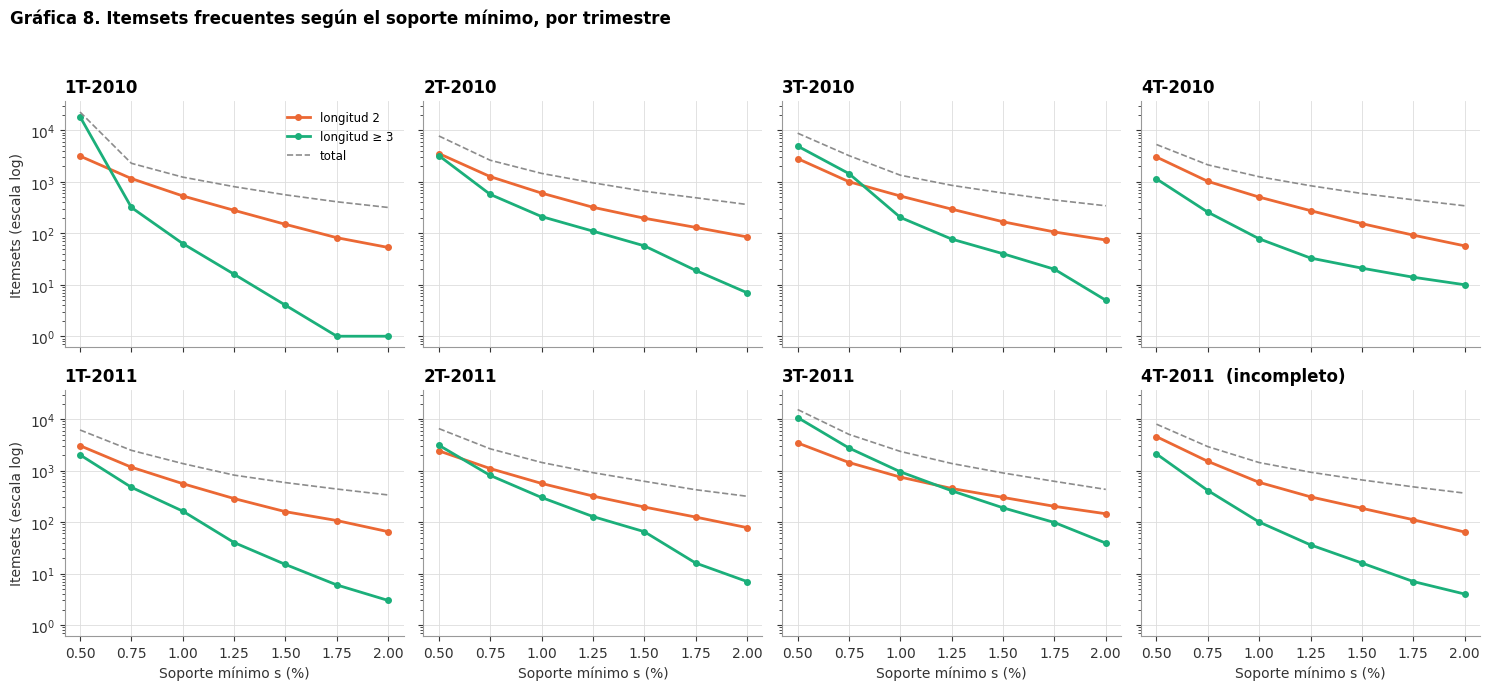

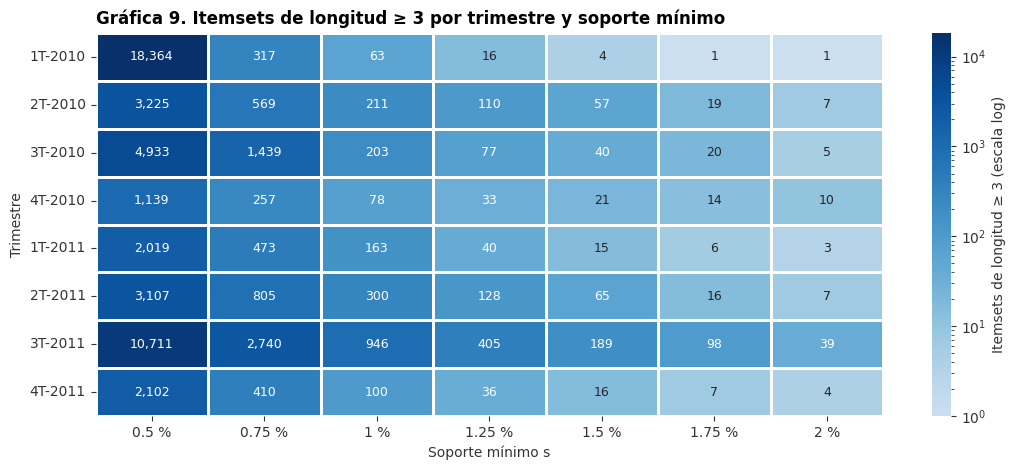

In [42]:
# Small multiples: itemsets por longitud contra s, y heatmap trimestre × s de los itemsets de longitud ≥ 3
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharex=True, sharey=True)
for ax, q in zip(axes.ravel(), TRIM_ANALISIS):
    d = barridos[q]
    for col, clave in [("longitud 2", "2"), ("longitud ≥ 3", "3")]:
        ax.plot(100 * d.index, d[col].replace(0, np.nan), color=COLOR_LONGITUD[clave], linewidth=2, marker="o",
                markersize=4, label=col)
    ax.plot(100 * d.index, d["itemsets"], color=GRIS, linewidth=1.2, linestyle="--", label="total")
    ax.set_yscale("log")
    estilo_ejes(ax, q + ("  (incompleto)" if not COMPLETO[q] else ""), rejilla="both")
for ax in axes[1]:
    ax.set_xlabel("Soporte mínimo s (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Itemsets (escala log)")
axes[0, 0].legend(loc="upper right", fontsize=8.5)
fig.suptitle("Gráfica 8. Itemsets frecuentes según el soporte mínimo, por trimestre", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

mapa = barrido.pivot(index="trimestre", columns="s", values="longitud ≥ 3").reindex(TRIM_ANALISIS)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(mapa.replace(0, np.nan), ax=ax, cmap=CMAP_SEC, norm=LogNorm(vmin=1, vmax=mapa.max().max()),
            annot=mapa, fmt=",d", annot_kws={"fontsize": 9}, linewidths=1, linecolor="white",
            cbar_kws={"label": "Itemsets de longitud ≥ 3 (escala log)"})
ax.set_xticklabels([f"{100 * s:g} %" for s in mapa.columns])
estilo_ejes(ax, "Gráfica 9. Itemsets de longitud ≥ 3 por trimestre y soporte mínimo",
            "Soporte mínimo s", "Trimestre", rejilla=None)
plt.tight_layout()
plt.show()

**Observaciones y decisión: soporte mínimo**

- **Pasada 1.** Los productos frecuentes caen de entre 1,002 y 1,308 con $s$ = 0.5 % a entre 232 y 297 con
  $s$ = 2 %. El barrido completo (56 corridas de FP-Growth) toma del orden de **medio minuto** y cada corrida, **un par de segundos o menos** (los tiempos exactos varían entre ejecuciones y están en la tabla):
  sin las facturas sin cliente, el costo ya no es una restricción.
- **Gráficas 8 y 9.**
  - Los itemsets de **longitud 2** bajan de forma gradual: entre 24 y 71 veces menos de $s$ = 0.5 % a $s$ = 2 %.
  - Los de **longitud ≥ 3** son mucho más sensibles. Con $s$ = 2 % casi desaparecen (de **1** en 1T-2010 a **39** en
    3T-2011).
  - Con $s$ = 0.5 % se disparan en dos trimestres: **18,364** en 1T-2010 (longitud máxima **14**) y **10,711** en 3T-2011.
  - En 3T-2010, ya con $s$ = 0.75 %, aparecen cadenas de longitud **10**.
  - Esos saltos tienen la misma forma que la explosión de la sección 2.1, aunque son más pequeños: grupos de facturas,
    ahora con cliente, que comparten muchos productos. Por debajo de 1 % se mezclarían en el análisis.
- **Con $s$ = 1 %** ningún trimestre muestra ese comportamiento:
  - la longitud máxima va de **3 a 6**;
  - cada trimestre conserva entre **63** (1T-2010) y **946** (3T-2011) itemsets de longitud ≥ 3, suficientes para estudiar
    reglas largas;
  - $\sigma$ va de **32.9** a **60.7** facturas.
  - Con $s$ = 1.5 % el 1T-2010 se queda con solo **4** itemsets de longitud ≥ 3.

| Opción | A favor | En contra |
|---|---|---|
| **Umbral común** ($s$ = 1 % en todos) | La pregunta es la misma en todos los trimestres (¿está en al menos el 1 % de las facturas?), así que una regla presente en un trimestre y ausente en otro refleja un cambio del patrón, no un cambio de umbral. Es simple y reproducible. | El respaldo en facturas varía de 32.9 a 60.7 según $N_q$: los trimestres pequeños admiten patrones con menos evidencia absoluta. |
| **Umbral por trimestre** (p. ej. $\sigma$ ≈ 40 facturas en todos, de $s$ ≈ 0.66 % en 4T-2010 a 1.22 % en 1T-2011) | Igual evidencia absoluta por patrón. | La comparación de la sección 7 queda contaminada: una regla podría "aparecer" en el 4T-2010 solo porque ahí el umbral relativo es más bajo. Además, 0.66 % cae en la zona donde ya aparecen cadenas largas. |

**Decisión: $s$ = 1 % común a los 8 trimestres** (constante `MIN_SUP`). El objetivo central es comparar trimestres, y
para eso importa más que la regla de selección sea la misma. La diferencia de respaldo absoluto se controla en la
sección 8, donde se marcan las reglas con pocas facturas o pocos clientes. El diccionario `MIN_SUP_TRIM` permite probar
umbrales por trimestre cambiando una sola celda.

In [43]:
# Decisión del soporte mínimo (constante fácil de cambiar)
MIN_SUP = 0.01
# Umbral por trimestre: por defecto el mismo s en todos. Para probar umbrales distintos, editar este diccionario.
MIN_SUP_TRIM = {q: MIN_SUP for q in TRIM_ANALISIS}
display(pd.DataFrame({"s": MIN_SUP_TRIM, "N": N_trim,
                      "σ = s·N (facturas)": {q: round(MIN_SUP_TRIM[q] * N_trim[q], 1) for q in TRIM_ANALISIS},
                      "s equivalente a σ = 40 facturas (%)": {q: round(100 * 40 / N_trim[q], 2) for q in TRIM_ANALISIS}}))

,s,N,σ = s·N (facturas),s equivalente a σ = 40 facturas (%)
1T-2010,0.01,3561,35.6,1.12
2T-2010,0.01,4159,41.6,0.96
3T-2010,0.01,4297,43.0,0.93
4T-2010,0.01,6072,60.7,0.66
1T-2011,0.01,3287,32.9,1.22
2T-2011,0.01,4073,40.7,0.98
3T-2011,0.01,4327,43.3,0.92
4T-2011,0.01,5321,53.2,0.75


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · FP-GROWTH</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Itemsets frecuentes por trimestre</span></div>


Con el umbral elegido se ejecuta FP-Growth en cada trimestre **sin `max_len`**, para obtener los itemsets frecuentes de
todas las longitudes. Esto es necesario porque `association_rules` calcula la confianza de $A \Rightarrow C$ como
$\text{sop}(A \cup C)/\text{sop}(A)$ y el lift con $\text{sop}(C)$. Si faltaran los itemsets cortos, no podría evaluar
las reglas que salen de los largos. La propiedad de cerradura hacia abajo garantiza que todos esos subconjuntos están en
la tabla, porque si $A \cup C$ es frecuente, también lo son $A$ y $C$.

`facturas` es el número de facturas del trimestre que contienen el itemset ($\text{sop} \cdot N_q$).

grupo,1,2,3,4+,total,longitud máxima,tiempo (s)
1T-2010,638,531,63,0,1232,3,0.45
2T-2010,642,603,173,38,1456,6,0.45
3T-2010,609,529,163,40,1341,4,0.95
4T-2010,671,504,72,6,1253,4,0.73
1T-2011,648,557,143,20,1368,5,0.38
2T-2011,575,563,237,63,1438,6,0.35
3T-2011,662,747,600,346,2355,5,1.23
4T-2011,741,590,96,4,1431,4,0.99


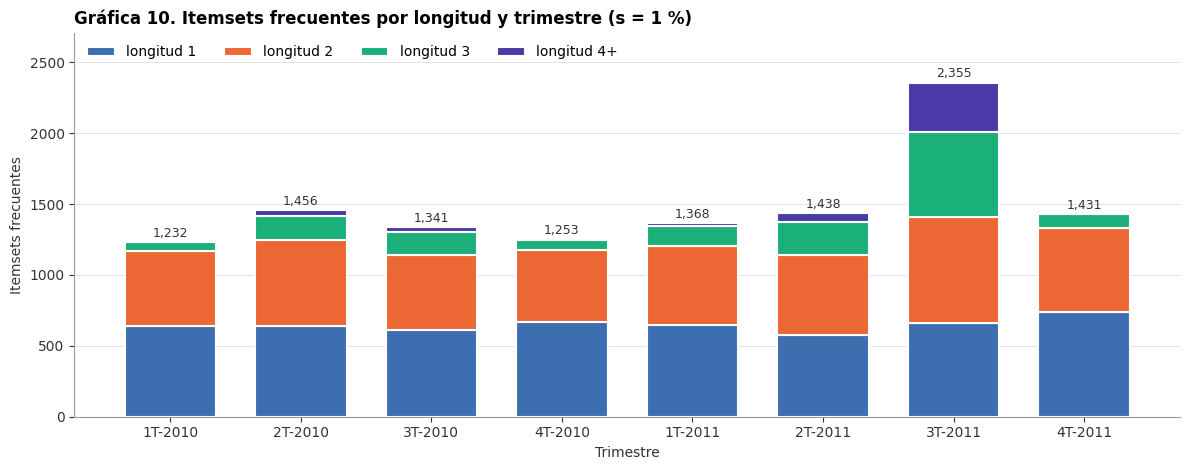

In [44]:
# FP-Growth con el umbral elegido, todas las longitudes
def grupo_longitud(k):
    """Agrupa una longitud de itemset o de regla en '1', '2', '3' o '4+'."""
    return "4+" if k >= 4 else str(k)


def nombre_producto(codigo, largo=34):
    """Descripción abreviada de un StockCode."""
    d = etiquetas.get(codigo, codigo)
    return d if len(d) <= largo else d[: largo - 1] + "…"


def nombre(codigos, largo=34):
    """Etiqueta legible de un conjunto de StockCode, con las descripciones ordenadas alfabéticamente."""
    return " + ".join(sorted(nombre_producto(c, largo) for c in codigos))


itemsets, tiempos = {}, {}
for q in TRIM_ANALISIS:
    t0 = time.perf_counter()
    fi = fpgrowth(X_trim[q], min_support=MIN_SUP_TRIM[q], use_colnames=True)
    tiempos[q] = time.perf_counter() - t0
    fi["longitud"] = fi["itemsets"].map(len)
    fi["grupo"] = fi["longitud"].map(grupo_longitud)
    fi["facturas"] = (fi["support"] * N_trim[q]).round().astype(int)
    itemsets[q] = fi

por_longitud = (pd.DataFrame({q: fi["grupo"].value_counts() for q, fi in itemsets.items()}).T
                .reindex(columns=["1", "2", "3", "4+"]).fillna(0).astype(int))
por_longitud["total"] = por_longitud.sum(axis=1)
por_longitud["longitud máxima"] = [itemsets[q]["longitud"].max() for q in TRIM_ANALISIS]
por_longitud["tiempo (s)"] = [round(tiempos[q], 2) for q in TRIM_ANALISIS]
display(por_longitud)

fig, ax = plt.subplots(figsize=(12, 4.8))
base = np.zeros(len(TRIM_ANALISIS))
for clave in ["1", "2", "3", "4+"]:
    v = por_longitud[clave].values
    ax.bar(TRIM_ANALISIS, v, bottom=base, color=COLOR_LONGITUD[clave], width=0.7, edgecolor="white", linewidth=1.5,
           label=f"longitud {clave}")
    base += v
for x, total in enumerate(base):
    ax.text(x, total * 1.01, f"{total:,.0f}", ha="center", va="bottom", fontsize=9, color=TINTA)
estilo_ejes(ax, f"Gráfica 10. Itemsets frecuentes por longitud y trimestre (s = {100 * MIN_SUP:g} %)", "Trimestre",
            "Itemsets frecuentes")
ax.legend(ncol=4, loc="upper left")
ax.set_ylim(0, base.max() * 1.15)
plt.tight_layout()
plt.show()

In [45]:
# Itemsets más frecuentes de longitud 2 y de longitud ≥ 3 (agregados sobre los trimestres)
todos_fi = pd.concat([fi.assign(trimestre=q) for q, fi in itemsets.items()], ignore_index=True)


def top_itemsets(condicion, n=10):
    """
    Resume los itemsets que cumplen una condición sobre todos los trimestres y devuelve los n de mayor soporte medio.

    Parámetros
    ----------
    condicion : pd.Series
        Máscara booleana sobre `todos_fi`.
    n : int
        Número de itemsets a mostrar.

    Retorna
    -------
    pd.DataFrame
        Itemset legible, trimestres en que es frecuente, soporte medio y máximo (%) y facturas en su mejor trimestre.
    """
    d = todos_fi[condicion]
    res = d.groupby("itemsets").agg(trimestres=("trimestre", "nunique"), soporte_medio=("support", "mean"),
                                    soporte_max=("support", "max"), facturas_max=("facturas", "max"),
                                    longitud=("longitud", "first"))
    res.index = [nombre(s) for s in res.index]
    res = res.rename_axis("Itemset").reset_index().sort_values(["soporte_medio", "Itemset"], ascending=[False, True])
    res = res.head(n).set_index("Itemset")
    res["soporte_medio"] = (100 * res["soporte_medio"]).round(2)
    res["soporte_max"] = (100 * res["soporte_max"]).round(2)
    return res.rename(columns={"trimestres": f"trimestres (de {len(TRIM_ANALISIS)})", "soporte_medio": "soporte medio (%)",
                               "soporte_max": "soporte máximo (%)", "facturas_max": "facturas (máx.)"}).rename_axis("Itemset")


q_max = por_longitud["4+"].idxmax()
largos = itemsets[q_max][itemsets[q_max]["longitud"] >= 4]
frec_largos = (pd.Series([p for s in largos["itemsets"] for p in s]).value_counts().sort_index()
               .sort_values(ascending=False, kind="mergesort"))
print(f"Trimestre con más itemsets de longitud ≥ 4: {q_max} ({len(largos):,}). Productos que más se repiten en ellos:")
display(frec_largos.head(10).rename("itemsets de long. ≥ 4 que lo contienen").to_frame()
        .assign(producto=lambda d: etiquetas.reindex(d.index).values)
        .assign(**{"soporte en el trimestre (%)": lambda d: (100 * conteo_columnas(X_trim[q_max])[d.index] / N_trim[q_max]).round(2).values}))
print(f"Esos {len(frec_largos)} productos forman los {len(largos):,} itemsets; los 10 más repetidos aparecen en el "
      f"{pct(largos['itemsets'].map(lambda s: bool(s & set(frec_largos.head(10).index))).mean(), 1)} de ellos.")

print("Itemsets de longitud 2 con mayor soporte medio")
display(top_itemsets(todos_fi["longitud"] == 2))
print("Itemsets de longitud ≥ 3 con mayor soporte medio")
display(top_itemsets(todos_fi["longitud"] >= 3))

Trimestre con más itemsets de longitud ≥ 4: 3T-2011 (346). Productos que más se repiten en ellos:


,itemsets de long. ≥ 4 que lo contienen,producto,soporte en el trimestre (%)
20725,157,LUNCH BAG RED RETROSPOT,8.97
22383,151,LUNCH BAG SUKI DESIGN,7.49
22384,130,LUNCH BAG PINK POLKADOT,7.28
22382,128,LUNCH BAG SPACEBOY DESIGN,6.66
23209,128,LUNCH BAG VINTAGE DOILY,9.78
23206,110,LUNCH BAG APPLE DESIGN,7.65
20727,109,LUNCH BAG BLACK SKULL.,7.74
20728,103,LUNCH BAG CARS BLUE,7.37
20726,93,LUNCH BAG WOODLAND,5.73
23208,48,LUNCH BAG VINTAGE LEAF DESIGN,5.13


Esos 47 productos forman los 346 itemsets; los 10 más repetidos aparecen en el 90.8 % de ellos.
Itemsets de longitud 2 con mayor soporte medio


,trimestres (de 8),soporte medio (%),soporte máximo (%),facturas (máx.),longitud
Itemset,,,,,
PAPER CHAIN KIT 50S CHRISTMAS + PAPER CHAIN KIT VINTAGE CHRISTMAS,3,4.00,5.54,295,2
JUMBO BAG RED RETROSPOT + JUMBO BAG VINTAGE DOILY,3,3.42,4.95,214,2
ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKELIKE RED,4,3.36,3.70,201,2
GARDENERS KNEELING PAD CUP OF TEA + GARDENERS KNEELING PAD KEEP CALM,3,3.33,3.80,202,2
SET OF 3 CAKE TINS PANTRY DESIGN + SET OF 6 SPICE TINS PANTRY DESIGN,2,3.31,5.38,177,2
JUMBO BAG VINTAGE DOILY + LUNCH BAG VINTAGE DOILY,3,3.31,4.46,193,2
JUMBO BAG VINTAGE DOILY + JUMBO BAG VINTAGE LEAF,3,3.18,4.30,186,2
BLUE FELT EASTER EGG BASKET + PINK FELT EASTER EGG BASKET,1,3.17,3.17,113,2
HAND WARMER OWL DESIGN + HAND WARMER RED LOVE HEART,1,3.12,3.12,166,2


Itemsets de longitud ≥ 3 con mayor soporte medio


,trimestres (de 8),soporte medio (%),soporte máximo (%),facturas (máx.),longitud
Itemset,,,,,
POPPYS PLAYHOUSE BATHROOM + POPPYS PLAYHOUSE KITCHEN + POPPYS PLAYHOUSE LIVINGROOM,1,2.47,2.47,150,3
POPPYS PLAYHOUSE BATHROOM + POPPYS PLAYHOUSE BEDROOM + POPPYS PLAYHOUSE LIVINGROOM,1,2.32,2.32,141,3
POPPYS PLAYHOUSE BATHROOM + POPPYS PLAYHOUSE BEDROOM + POPPYS PLAYHOUSE KITCHEN + POPPYS PLAYHOUSE LIVINGROOM,1,2.29,2.29,139,4
HAND WARMER BIRD DESIGN + HAND WARMER OWL DESIGN + HAND WARMER SCOTTY DOG DESIGN,2,2.27,2.50,152,3
JUMBO BAG APPLES + JUMBO BAG RED RETROSPOT + JUMBO BAG VINTAGE DOILY,1,2.20,2.20,95,3
JUMBO BAG RED RETROSPOT + JUMBO BAG VINTAGE DOILY + LUNCH BAG RED RETROSPOT,1,2.15,2.15,93,3
BLUE FELT EASTER EGG BASKET + CREAM FELT EASTER EGG BASKET + PINK FELT EASTER EGG BASKET,1,2.13,2.13,76,3
LUNCH BAG SPACEBOY DESIGN + LUNCH BAG SUKI DESIGN + LUNCH BAG VINTAGE DOILY,1,2.13,2.13,92,3
JAM MAKING SET WITH JARS + SET OF 3 CAKE TINS PANTRY DESIGN + SET OF 6 SPICE TINS PANTRY DESIGN,1,2.10,2.10,69,3


**Observaciones: itemsets frecuentes**

- **Gráfica 10.** Siete trimestres tienen entre **1,232** y **1,456** itemsets, y en todos predominan los de longitud 1
  (575 a 741) y 2 (504 a 603).
  - **1T-2010** no tiene ningún itemset de longitud 4+, y el **4T** de ambos años casi tampoco (**6** y **4**).
  - La excepción es el **3T-2011**: **2,355** itemsets, con **600** de longitud 3 y **346** de longitud 4+.
- **Por qué destaca el 3T-2011.** Los productos que más se repiten en sus itemsets largos son la línea **`LUNCH BAG`**
  (`RED RETROSPOT`, `SUKI`, `PINK POLKADOT`, `VINTAGE DOILY`, `SPACEBOY`…), cada una con soporte de entre **5.13 %** y
  **9.78 %** en el trimestre. Los 10 productos más repetidos están en el **90.8 %** de los 346 itemsets de longitud ≥ 4. Es
  la temporada de **regreso a clases** (julio a septiembre): los clientes compran varios diseños de lonchera a la vez, y esa
  combinatoria de diseños genera muchos itemsets largos.
- **Pares más frecuentes** (soporte medio en los trimestres donde son frecuentes):
  - `PAPER CHAIN KIT 50S CHRISTMAS + VINTAGE CHRISTMAS`: **4.00 %**, frecuente solo en 3 trimestres, con un máximo de
    **295 facturas**. Es un par navideño.
  - `JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT`: **3.09 %**, frecuente en **los 8 trimestres**.
  - Casi todos los pares son **dos diseños del mismo artículo** (bolsas, relojes despertadores `BAKELIKE` en verde y rojo,
    almohadillas de jardinería `GARDENERS KNEELING PAD`, canastas de Pascua).
- **Tríos y cuartetos más frecuentes.** Son colecciones: la casita de muñecas `POPPYS PLAYHOUSE` (baño, cocina, sala y
  recámara; **2.47 %**, **150 facturas**), calentadores de manos `HAND WARMER` en tres diseños, bolsas `JUMBO BAG` y la línea
  `PANTRY DESIGN`. Casi todos son frecuentes en **1 o 2 trimestres**, lo que adelanta que los patrones largos son más
  estacionales que los pares.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · REGLAS</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Reglas de asociación por trimestre</span></div>


De cada itemset frecuente $Z$ con $|Z| \ge 2$ salen las reglas $A \Rightarrow C$ con $A \cup C = Z$, $A \cap C = \emptyset$ y
ambos no vacíos. Se evalúan con tres medidas, cada una de las cuales responde a una pregunta distinta:

| Medida | Definición | Pregunta en la tienda |
|---|---|---|
| Soporte | $\text{sop}(A \cup C)$ | ¿Qué fracción de las facturas del trimestre contiene todos los productos de la regla? |
| Confianza | $\text{sop}(A \cup C) / \text{sop}(A)$ | De las facturas con $A$, ¿qué fracción también tiene $C$? |
| Lift | $\text{conf}(A \Rightarrow C) / \text{sop}(C)$ | ¿Cuántas veces más probable es $C$ cuando está $A$ que en una factura cualquiera? |

La confianza sola engaña cuando $C$ es muy común: una confianza de 0.4 hacia un producto que está en el 15 % de las
facturas es poco informativa. El lift corrige eso comparando con la frecuencia base de $C$. Un lift de 1 indica
independencia, y un lift mayor que 1 indica que los productos aparecen juntos más de lo esperado.

Se generan **todas** las reglas posibles con `association_rules(..., metric="confidence", min_threshold=0)` a partir de la
tabla **completa** de itemsets de cada trimestre, y se registra su **longitud** $|A \cup C|$ (2, 3 o 4+). Así se incluyen
las reglas de 2 productos (A → B) y las más largas (A, B → C; A → B, C; …). Los umbrales de confianza y lift se eligen
después de ver su distribución.

Reglas candidatas (todas las confianzas): 26,808


grupo                    2         3        4+
confidence count  9248.000  9282.000  8278.000
           mean      0.346     0.430     0.496
           std       0.183     0.228     0.253
           min       0.053     0.055     0.089
           25%       0.197     0.225     0.297
           50%       0.315     0.410     0.458
           75%       0.463     0.602     0.710
           90%       0.607     0.753     0.865
           max       0.962     1.000     1.000
lift       count  9248.000  9282.000  8278.000
           mean      9.473    13.005    19.115
           std       9.680    10.926    15.692
           min       0.986     1.502     3.988
           25%       3.205     7.211     9.678
           50%       6.191     8.930    12.160
           75%      11.459    13.468    18.865
           90%      22.911    27.930    49.396
           max      68.342    71.740    83.697

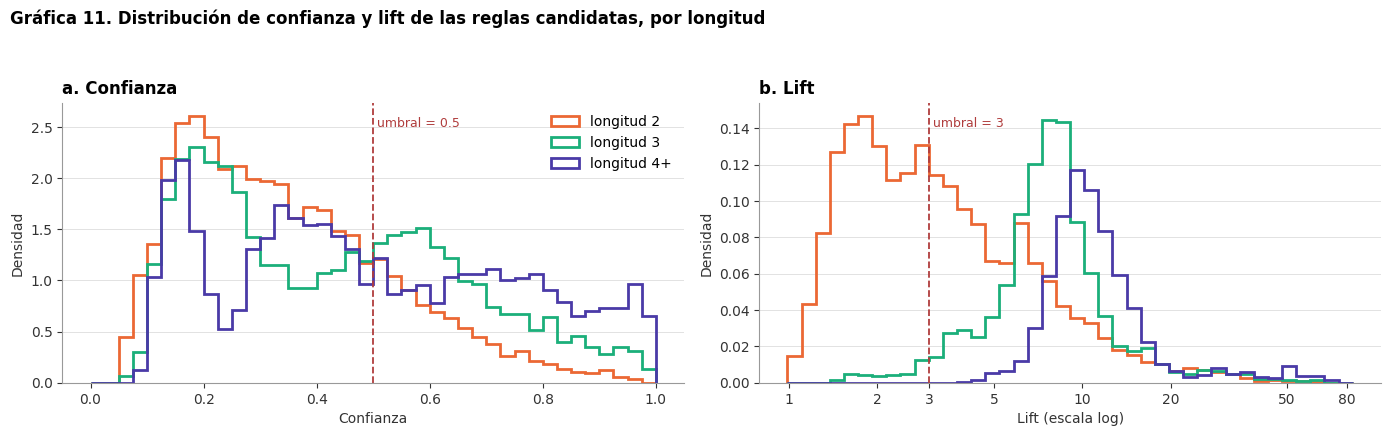

Lift < 1 (asociación negativa): 0.01 % | confianza ≥ 0.5: 34.79 %


In [46]:
# Todas las reglas candidatas que salen de los itemsets frecuentes (sin umbral de confianza)
def reglas_trimestre(fi, n, q):
    """
    Genera todas las reglas de un trimestre con association_rules a partir de la tabla COMPLETA de itemsets.

    Parámetros
    ----------
    fi : pd.DataFrame
        Itemsets frecuentes de todas las longitudes (columnas support e itemsets).
    n : int
        Número de transacciones del trimestre.
    q : str
        Etiqueta del trimestre.

    Retorna
    -------
    pd.DataFrame
        Reglas con soporte, confianza, lift, longitud, grupo de longitud y número de facturas que las respaldan.
    """
    r = association_rules(fi[["support", "itemsets"]], num_itemsets=n, metric="confidence", min_threshold=0.0)
    r = r[["antecedents", "consequents", "antecedent support", "consequent support", "support", "confidence", "lift"]].copy()
    r["trimestre"] = q
    r["longitud"] = r["antecedents"].map(len) + r["consequents"].map(len)
    r["grupo"] = r["longitud"].map(grupo_longitud)
    r["facturas"] = (r["support"] * n).round().astype(int)
    return r


reglas_todas = pd.concat([reglas_trimestre(itemsets[q], N_trim[q], q) for q in TRIM_ANALISIS], ignore_index=True)
print(f"Reglas candidatas (todas las confianzas): {len(reglas_todas):,}")
display(reglas_todas.groupby("grupo")[["confidence", "lift"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(3).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for clave in ["2", "3", "4+"]:
    d = reglas_todas[reglas_todas["grupo"] == clave]
    axes[0].hist(d["confidence"], bins=np.linspace(0, 1, 41), histtype="step", linewidth=2,
                 color=COLOR_LONGITUD[clave], density=True, label=f"longitud {clave}")
    axes[1].hist(d["lift"], bins=np.logspace(np.log10(reglas_todas["lift"].min()), np.log10(reglas_todas["lift"].max()), 41),
                 histtype="step", linewidth=2, color=COLOR_LONGITUD[clave], density=True, label=f"longitud {clave}")
axes[1].set_xscale("log")
marcas_log(axes[1].xaxis, 0.9, reglas_todas["lift"].max() * 1.1)
for ax, umbral, titulo, xlabel in [(axes[0], 0.5, "a. Confianza", "Confianza"),
                                    (axes[1], 3, "b. Lift", "Lift (escala log)")]:
    ax.axvline(umbral, color=ROJO, linestyle="--", linewidth=1.3)
    ax.text(umbral, ax.get_ylim()[1] * 0.95, f" umbral = {umbral:g}", color=ROJO, fontsize=9, va="top")
    estilo_ejes(ax, titulo, xlabel, "Densidad")
axes[0].legend(loc="upper right")
fig.suptitle("Gráfica 11. Distribución de confianza y lift de las reglas candidatas, por longitud", x=0.01, ha="left",
             fontweight="bold", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()
print(f"Lift < 1 (asociación negativa): {pct((reglas_todas['lift'] < 1).mean())} | "
      f"confianza ≥ 0.5: {pct((reglas_todas['confidence'] >= 0.5).mean())}")

**Observaciones y decisión: umbrales de confianza y lift**

- **Volumen.** De los itemsets frecuentes salen **26,808** reglas candidatas: **9,248** de longitud 2, **9,282** de
  longitud 3 y **8,278** de longitud 4+.
- **Confianza (Gráfica 11a).** Sube con la longitud: la mediana es **0.315** en longitud 2, **0.410** en longitud 3 y
  **0.458** en 4+. Cuanto más específico es el antecedente, más seguro es el consecuente.
- **Lift (Gráfica 11b).** Es alto en casi todas: la mediana es **6.19**, **8.93** y **12.16** según la longitud, y solo el
  **0.01 %** de las reglas tiene lift < 1. Con soporte mínimo de 1 % y productos de soporte bajo, casi cualquier par que
  llega a ser frecuente co-ocurre por encima del azar.

**Decisión:**
- **`CONF_MIN = 0.5`.** El consecuente debe aparecer en **al menos la mitad** de las facturas que contienen el antecedente,
  es decir, ser más probable que no. Es el criterio mínimo para recomendar "quien compra A, compra B". Queda en el cuartil
  superior de las reglas de longitud 2 (su p75 es 0.463) y deja pasar el **34.79 %** de las candidatas.
- **`LIFT_MIN = 3`.** Exige que $C$ sea **al menos 3 veces más probable** cuando está $A$ que en una factura cualquiera.
  - En estos datos casi no filtra: de las **9,326** reglas con confianza ≥ 0.5, solo **6** tienen lift < 3 (el mínimo es
    **2.67**).
  - Es algo esperado: el producto más frecuente de cada trimestre tiene soporte de entre **10.82 %** y **18.96 %**, así que
    una confianza de 0.5 ya implica un lift de al menos $0.5/0.1896 \approx 2.64$.
  - Se mantiene como **garantía explícita**: si se baja `CONF_MIN` o se cambia de dataset, el lift sigue protegiendo contra
    consecuentes muy comunes.

Resultado: **9,320 reglas**.

In [47]:
# Filtrado con los umbrales de confianza y lift; conteos por trimestre y longitud
CONF_MIN = 0.5
LIFT_MIN = 3
reglas = reglas_todas[(reglas_todas["confidence"] >= CONF_MIN) & (reglas_todas["lift"] >= LIFT_MIN)].copy()
reglas["regla"] = [f"{nombre(a)} → {nombre(c)}" for a, c in zip(reglas["antecedents"], reglas["consequents"])]

# Facturas y clientes distintos que respaldan cada regla (las facturas que contienen A ∪ C)
for q in TRIM_ANALISIS:
    m = X_trim[q].sparse.to_coo().tocsc()
    filas_item = {c: set(m.indices[m.indptr[j]:m.indptr[j + 1]]) for j, c in enumerate(X_trim[q].columns)}
    clientes_q = canastas_trim[q]["cliente"].to_numpy()
    sel = reglas["trimestre"] == q
    reglas.loc[sel, "clientes"] = [
        len(set(clientes_q[list(set.intersection(*(filas_item[i] for i in a | c)))]))
        for a, c in zip(reglas.loc[sel, "antecedents"], reglas.loc[sel, "consequents"])]
reglas["clientes"] = reglas["clientes"].astype(int)

conteo_reglas = (pd.crosstab(reglas["trimestre"], reglas["grupo"]).reindex(index=TRIM_ANALISIS, columns=["2", "3", "4+"])
                 .fillna(0).astype(int))
conteo_reglas["total"] = conteo_reglas.sum(axis=1)
conteo_reglas["candidatas"] = reglas_todas.groupby("trimestre").size().reindex(TRIM_ANALISIS)
conteo_reglas["% que pasa"] = (100 * conteo_reglas["total"] / conteo_reglas["candidatas"]).round(2)
conf_ok = reglas_todas["confidence"] >= CONF_MIN
print(f"Reglas con confianza ≥ {CONF_MIN}: {conf_ok.sum():,}; de ellas, con lift < {LIFT_MIN}: "
      f"{(conf_ok & (reglas_todas['lift'] < LIFT_MIN)).sum():,} (lift mínimo entre ellas: {reglas_todas.loc[conf_ok, 'lift'].min():.2f})")
print("Soporte del producto más frecuente por trimestre (si C es ese producto, conf = 0.5 implica lift = 0.5 / sop(C)):")
print({q: round(itemsets[q].loc[itemsets[q]['longitud'] == 1, 'support'].max(), 4) for q in TRIM_ANALISIS})
print(f"Reglas con confianza ≥ {CONF_MIN} y lift ≥ {LIFT_MIN}: {len(reglas):,} de {len(reglas_todas):,}")
display(conteo_reglas)

columnas_regla = ["regla", "trimestre", "longitud", "support", "confidence", "lift", "facturas", "clientes"]


def tabla_reglas(df):
    """Formatea reglas para mostrarlas: soporte en %, confianza y lift redondeados."""
    t = df[columnas_regla].copy()
    t["support"] = (100 * t["support"]).round(2)
    t[["confidence", "lift"]] = t[["confidence", "lift"]].round(3)
    return t.rename(columns={"support": "soporte (%)", "confidence": "confianza"}).reset_index(drop=True)


print("Mejor regla de cada longitud (mayor lift; empates: mayor soporte y orden alfabético de la regla)")
mejores = (reglas.sort_values(["lift", "support", "regla"], ascending=[False, False, True]).groupby("grupo").head(1)
           .sort_values("longitud"))
display(tabla_reglas(mejores))

Reglas con confianza ≥ 0.5: 9,326; de ellas, con lift < 3: 6 (lift mínimo entre ellas: 2.67)
Soporte del producto más frecuente por trimestre (si C es ese producto, conf = 0.5 implica lift = 0.5 / sop(C)):
{'1T-2010': np.float64(0.1896), '2T-2010': np.float64(0.1618), '3T-2010': np.float64(0.1529), '4T-2010': np.float64(0.138), '1T-2011': np.float64(0.136), '2T-2011': np.float64(0.1336), '3T-2011': np.float64(0.1082), '4T-2011': np.float64(0.1212)}
Reglas con confianza ≥ 0.5 y lift ≥ 3: 9,320 de 26,808


grupo,2,3,4+,total,candidatas,% que pasa
trimestre,,,,,,
1T-2010,195,142,0,337,1440,23.40
2T-2010,278,476,508,1262,2920,43.22
3T-2010,243,404,210,857,2596,33.01
4T-2010,182,179,33,394,1524,25.85
1T-2011,281,445,277,1003,2284,43.91
2T-2011,227,569,862,1658,3718,44.59
3T-2011,288,1232,1857,3377,10514,32.12
4T-2011,180,228,24,432,1812,23.84


Mejor regla de cada longitud (mayor lift; empates: mayor soporte y orden alfabético de la regla)


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes
0,PACK OF 6 SKULL PAPER CUPS → PACK OF 6 SKULL PAPER PLATES,1T-2010,2,1.07,0.864,68.342,38,37
1,CHILDS GARDEN FORK BLUE → CHILDS GARDEN FORK PINK + CHILDS GARDEN TROWEL BLUE,1T-2011,3,1.00,0.786,71.740,33,30
2,CHILDS GARDEN FORK BLUE + CHILDS GARDEN TROWEL PINK → CHILDS GARDEN FORK PINK + CHILDS GARDEN TR...,1T-2011,4,1.00,0.917,83.697,33,30


### Redundancia de las reglas largas

Una regla larga solo vale la pena si dice algo que sus versiones cortas no dicen. Para cada regla $A \Rightarrow C$ de
longitud $\ge 3$ se consideran todas sus **sub-reglas** $A' \Rightarrow C'$ con $A' \subseteq A$, $C' \subseteq C$, ambos no
vacíos y distinta de la original. Por ejemplo, $\{x, y\} \Rightarrow \{z\}$ tiene como sub-reglas $\{x\} \Rightarrow \{z\}$ y
$\{y\} \Rightarrow \{z\}$. Se calcula:

- **mejora de confianza** $= \text{conf}(A \Rightarrow C) - \max \text{conf}(A' \Rightarrow C')$ (la *improvement* de Bayardo,
  extendida a consecuentes);
- **mejora relativa de lift** $= \text{lift}(A \Rightarrow C) / \max \text{lift}(A' \Rightarrow C') - 1$.

Los soportes de las sub-reglas se toman de la tabla completa de itemsets, así que el cálculo no depende de que la sub-regla
haya pasado los umbrales. Una regla larga se considera **redundante** si no mejora la confianza en al menos
`MARGEN_CONF = 0.05` **ni** el lift en al menos `MARGEN_LIFT = 10 %`. El margen evita contar como "aporte" diferencias
del tamaño del ruido: con unas 50 facturas de respaldo, el error estándar de una confianza cercana a 0.6 es aproximadamente
$\sqrt{0.6 \cdot 0.4 / 50} \approx 0.07$.

Hay que tener en cuenta que, al agregar productos al consecuente, la confianza nunca sube, porque
$\text{sop}(A \cup C) \le \text{sop}(A \cup C')$. Una regla $A \Rightarrow \{B, C\}$ solo puede aportar lift.

In [48]:
# ¿Las reglas largas aportan algo sobre sus sub-reglas más cortas?
MARGEN_CONF = 0.05   # mejora mínima de confianza (puntos de proporción)
MARGEN_LIFT = 0.10   # mejora mínima relativa de lift (10 %)
soporte_dict = {q: dict(zip(fi["itemsets"], fi["support"])) for q, fi in itemsets.items()}


def mejora_sobre_subreglas(a, c, sop):
    """
    Compara una regla A → C con todas sus sub-reglas A' → C' (A' ⊆ A, C' ⊆ C, no vacíos, distinta de la original).

    Parámetros
    ----------
    a, c : frozenset
        Antecedente y consecuente.
    sop : dict
        Soporte de cada itemset frecuente del trimestre (todos los subconjuntos están, por cerradura hacia abajo).

    Retorna
    -------
    tuple of float
        (confianza máxima de las sub-reglas, lift máximo de las sub-reglas).
    """
    conf_max, lift_max = 0.0, 0.0
    for i in range(1, len(a) + 1):
        for a2 in map(frozenset, combinations(a, i)):
            for j in range(1, len(c) + 1):
                for c2 in map(frozenset, combinations(c, j)):
                    if a2 == a and c2 == c:
                        continue
                    conf = sop[a2 | c2] / sop[a2]
                    conf_max, lift_max = max(conf_max, conf), max(lift_max, conf / sop[c2])
    return conf_max, lift_max


largas = reglas["longitud"] >= 3
sub = [mejora_sobre_subreglas(a, c, soporte_dict[q])
       for a, c, q in zip(reglas.loc[largas, "antecedents"], reglas.loc[largas, "consequents"], reglas.loc[largas, "trimestre"])]
reglas.loc[largas, "conf_sub_max"] = [s[0] for s in sub]
reglas.loc[largas, "lift_sub_max"] = [s[1] for s in sub]
reglas["mejora_conf"] = reglas["confidence"] - reglas["conf_sub_max"]
reglas["mejora_lift_rel"] = reglas["lift"] / reglas["lift_sub_max"] - 1
reglas["aporta_conf"] = reglas["mejora_conf"] >= MARGEN_CONF
reglas["aporta_lift"] = reglas["mejora_lift_rel"] >= MARGEN_LIFT
reglas["redundante"] = largas & ~reglas["aporta_conf"] & ~reglas["aporta_lift"]

resumen_red = reglas[largas].groupby("grupo").agg(
    reglas=("regla", "size"), aporta_confianza=("aporta_conf", "mean"), aporta_lift=("aporta_lift", "mean"),
    redundantes=("redundante", "mean"), mejora_conf_mediana=("mejora_conf", "median"),
    mejora_lift_mediana=("mejora_lift_rel", "median"))
resumen_red[["aporta_confianza", "aporta_lift", "redundantes"]] *= 100
display(resumen_red.round(3).rename(columns={"aporta_confianza": "% aporta confianza", "aporta_lift": "% aporta lift",
                                             "redundantes": "% redundantes"}))

print("Ejemplos de reglas largas NO redundantes con mayor mejora de confianza:")
ej = reglas[largas & ~reglas["redundante"]].sort_values(["mejora_conf", "regla"], ascending=[False, True]).head(5)
display(tabla_reglas(ej).assign(**{"confianza sub-reglas (máx.)": ej["conf_sub_max"].round(3).values,
                                   "mejora conf.": ej["mejora_conf"].round(3).values}))
print("Ejemplos de reglas largas redundantes con mayor lift:")
ej = reglas[reglas["redundante"]].sort_values(["lift", "regla"], ascending=[False, True]).head(5)
display(tabla_reglas(ej).assign(**{"confianza sub-reglas (máx.)": ej["conf_sub_max"].round(3).values,
                                   "lift sub-reglas (máx.)": ej["lift_sub_max"].round(3).values}))

,reglas,% aporta confianza,% aporta lift,% redundantes,mejora_conf_mediana,mejora_lift_mediana
grupo,,,,,,
3,3675,73.905,73.741,22.422,0.097,0.187
4+,3771,26.863,36.516,56.404,-0.002,0.060


Ejemplos de reglas largas NO redundantes con mayor mejora de confianza:


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes,confianza sub-reglas (máx.),mejora conf.
0,JUMBO BAG RED RETROSPOT + LUNCH BAG VINTAGE DOILY → JUMBO BAG VINTAGE DOILY,4T-2011,3,1.03,0.846,12.683,55,50,0.383,0.463
1,JUMBO BAG VINTAGE DOILY + LUNCH BAG VINTAGE LEAF DESIGN → LUNCH BAG VINTAGE DOILY,2T-2011,3,1.25,0.895,12.877,51,45,0.495,0.400
2,JUMBO BAG RED RETROSPOT + LUNCH BAG APPLE DESIGN → JUMBO BAG APPLES,2T-2011,3,1.45,0.766,12.191,59,48,0.368,0.398
3,JUMBO BAG APPLES + JUMBO BAG VINTAGE DOILY → JUMBO BAG PEARS,2T-2011,3,1.47,0.741,22.515,60,49,0.344,0.397
4,JUMBO BAG BAROQUE BLACK WHITE + LUNCH BAG VINTAGE DOILY → JUMBO BAG VINTAGE DOILY,3T-2011,3,1.02,0.898,8.596,44,41,0.512,0.386


Ejemplos de reglas largas redundantes con mayor lift:


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes,confianza sub-reglas (máx.),lift sub-reglas (máx.)
0,CHILDS GARDEN FORK BLUE → CHILDS GARDEN FORK PINK + CHILDS GARDEN TROWEL BLUE + CHILDS GARDEN TR...,1T-2011,4,1.00,0.786,75.960,33,30,0.905,71.740
1,HERB MARKER CHIVES + HERB MARKER ROSEMARY → HERB MARKER MINT + HERB MARKER PARSLEY + HERB MARKER...,1T-2011,5,1.06,0.921,73.841,35,32,1.000,69.200
2,HERB MARKER MINT + HERB MARKER PARSLEY + HERB MARKER THYME → HERB MARKER CHIVES + HERB MARKER RO...,1T-2011,5,1.06,0.854,73.841,35,32,0.976,69.200
3,REGENCY MILK JUG PINK + REGENCY TEA PLATE GREEN + REGENCY TEA PLATE ROSES → REGENCY SUGAR BOWL G...,2T-2011,6,1.03,0.824,72.918,42,40,0.981,70.507
4,REGENCY SUGAR BOWL GREEN + REGENCY TEA PLATE PINK + REGENCY TEAPOT ROSES → REGENCY MILK JUG PINK...,2T-2011,6,1.03,0.913,72.918,42,40,0.978,70.507


### Vista conjunta por trimestre

La Gráfica 12 pone cada regla en un plano soporte–confianza, con color según el lift y forma según la longitud
(círculo = 2, triángulo = 3, cuadrado = 4+). Las tablas siguientes muestran las mejores reglas con etiquetas legibles, el
número de **facturas** que las respaldan ($\text{sop} \cdot N_q$) y el número de **clientes distintos** detrás de esas
facturas.

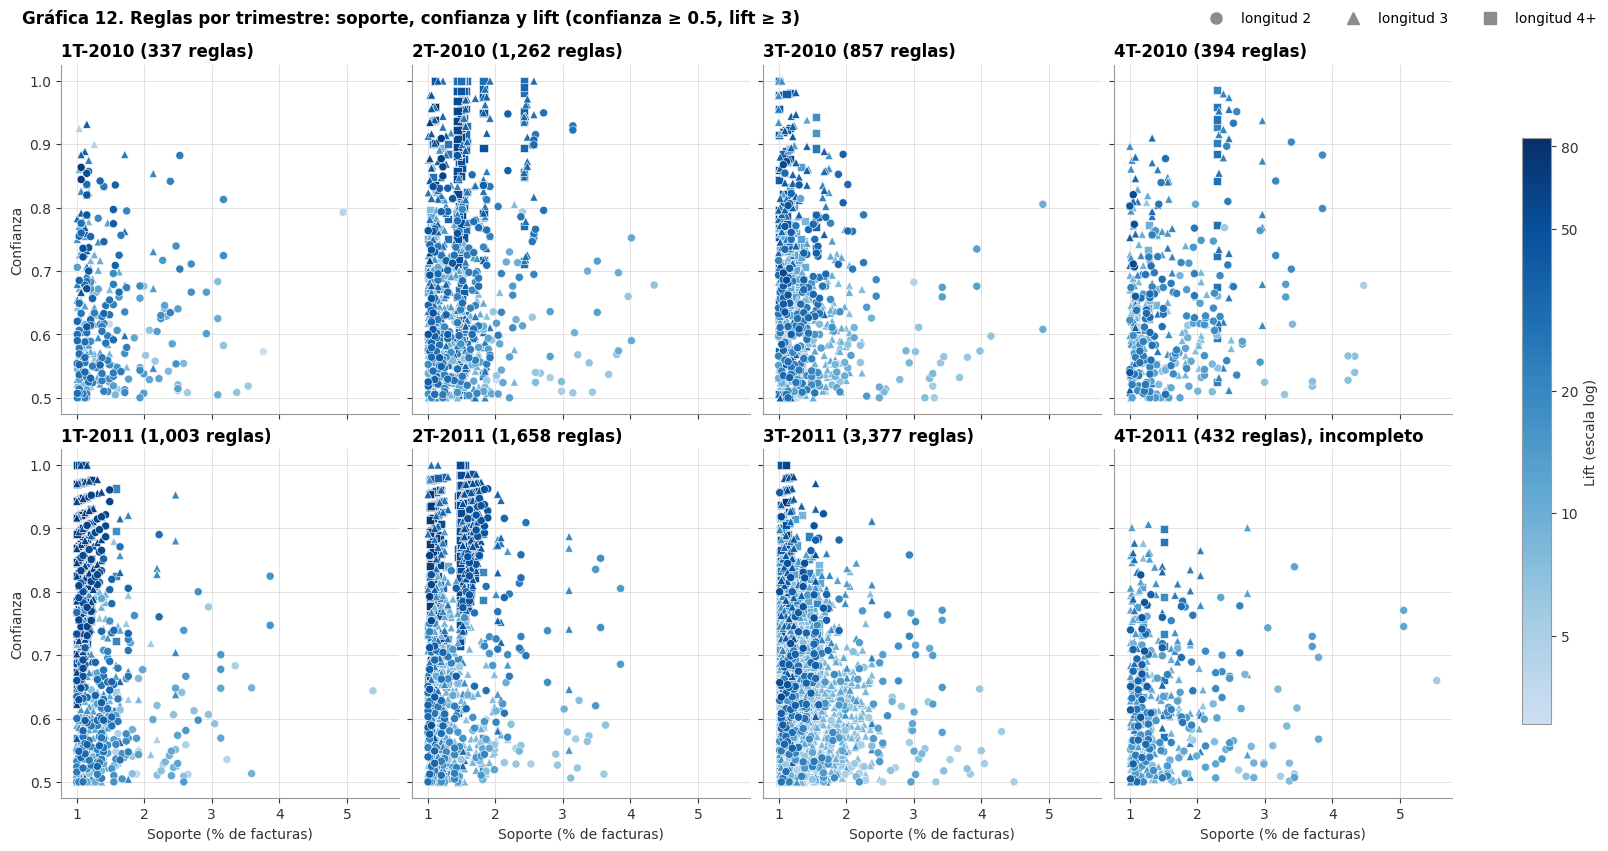

Las 15 reglas con mayor lift (cada regla una vez, en su trimestre de mayor lift)


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes
0,CHILDS GARDEN FORK BLUE + CHILDS GARDEN TROWEL PINK → CHILDS GARDEN FORK PINK + CHILDS GARDEN TR...,1T-2011,4,1.00,0.917,83.697,33,30
1,CHILDS GARDEN FORK PINK + CHILDS GARDEN TROWEL BLUE → CHILDS GARDEN FORK BLUE + CHILDS GARDEN TR...,1T-2011,4,1.00,0.917,83.697,33,30
2,CHILDS GARDEN BRUSH BLUE + CHILDS GARDEN TROWEL PINK → CHILDS GARDEN BRUSH PINK + CHILDS GARDEN ...,2T-2010,4,1.11,0.958,78.151,46,41
3,CHILDS GARDEN BRUSH PINK + CHILDS GARDEN TROWEL BLUE → CHILDS GARDEN BRUSH BLUE + CHILDS GARDEN ...,2T-2010,4,1.11,0.902,78.151,46,41
4,CHILDS GARDEN FORK BLUE → CHILDS GARDEN FORK PINK + CHILDS GARDEN TROWEL BLUE + CHILDS GARDEN TR...,1T-2011,4,1.00,0.786,75.960,33,30
5,CHILDS GARDEN FORK PINK + CHILDS GARDEN TROWEL BLUE + CHILDS GARDEN TROWEL PINK → CHILDS GARDEN ...,1T-2011,4,1.00,0.971,75.960,33,30
6,DOLLY GIRL CHILDRENS BOWL + SPACEBOY CHILDRENS CUP → DOLLY GIRL CHILDRENS CUP + SPACEBOY CHILDRE...,3T-2011,4,1.11,0.941,75.416,48,45
7,DOLLY GIRL CHILDRENS CUP + SPACEBOY CHILDRENS BOWL → DOLLY GIRL CHILDRENS BOWL + SPACEBOY CHILDR...,3T-2011,4,1.11,0.889,75.416,48,45
8,CHILDS GARDEN FORK BLUE + CHILDS GARDEN FORK PINK → CHILDS GARDEN TROWEL BLUE + CHILDS GARDEN TR...,1T-2011,4,1.00,0.971,74.194,33,30
9,CHILDS GARDEN TROWEL BLUE + CHILDS GARDEN TROWEL PINK → CHILDS GARDEN FORK BLUE + CHILDS GARDEN ...,1T-2011,4,1.00,0.767,74.194,33,30


Las 15 reglas no redundantes con mayor número de facturas


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes
0,PAPER CHAIN KIT VINTAGE CHRISTMAS → PAPER CHAIN KIT 50S CHRISTMAS,4T-2011,2,5.54,0.660,5.444,295,214
1,RED HANGING HEART T-LIGHT HOLDER → WHITE HANGING HEART T-LIGHT HOLDER,4T-2010,2,4.46,0.678,4.909,271,199
2,WOODEN HEART CHRISTMAS SCANDINAVI… → WOODEN STAR CHRISTMAS SCANDINAVIAN,4T-2011,2,5.06,0.771,11.361,269,210
3,WOODEN STAR CHRISTMAS SCANDINAVIAN → WOODEN HEART CHRISTMAS SCANDINAVI…,4T-2011,2,5.06,0.745,11.361,269,210
4,HAND WARMER OWL DESIGN → HAND WARMER SCOTTY DOG DESIGN,4T-2010,2,4.33,0.540,7.052,263,183
5,HAND WARMER SCOTTY DOG DESIGN → HAND WARMER OWL DESIGN,4T-2010,2,4.33,0.566,7.052,263,183
6,HAND WARMER BIRD DESIGN → HAND WARMER OWL DESIGN,4T-2010,2,4.23,0.566,7.058,257,185
7,HAND WARMER OWL DESIGN → HAND WARMER BIRD DESIGN,4T-2010,2,4.23,0.528,7.058,257,185
8,POPPYS PLAYHOUSE BEDROOM → POPPYS PLAYHOUSE KITCHEN,4T-2010,2,3.85,0.883,18.299,234,192
9,POPPYS PLAYHOUSE KITCHEN → POPPYS PLAYHOUSE BEDROOM,4T-2010,2,3.85,0.799,18.299,234,192


In [49]:
# Dispersión soporte vs confianza (color = lift, forma = longitud), un panel por trimestre
norma = LogNorm(vmin=reglas["lift"].min(), vmax=reglas["lift"].max())
fig, axes = plt.subplots(2, 4, figsize=(16, 8.4), sharex=True, sharey=True, layout="constrained")
for ax, q in zip(axes.ravel(), TRIM_ANALISIS):
    d = reglas[reglas["trimestre"] == q]
    for clave in ["4+", "3", "2"]:
        dd = d[d["grupo"] == clave].sort_values("lift")
        sc = ax.scatter(100 * dd["support"], dd["confidence"], c=dd["lift"], cmap=CMAP_SEC, norm=norma,
                        marker=MARCADOR_LONGITUD[clave], s=34, edgecolor="white", linewidth=0.4)
    estilo_ejes(ax, f"{q} ({len(d):,} reglas)" + (", incompleto" if not COMPLETO[q] else ""), rejilla="both")
for ax in axes[1]:
    ax.set_xlabel("Soporte (% de facturas)")
for ax in axes[:, 0]:
    ax.set_ylabel("Confianza")
barra = fig.colorbar(plt.cm.ScalarMappable(norm=norma, cmap=CMAP_SEC), ax=axes, shrink=0.8, label="Lift (escala log)")
marcas_log(barra, norma.vmin, norma.vmax)
fig.legend(handles=[Line2D([], [], marker=MARCADOR_LONGITUD[k], color=GRIS, linestyle="none", markersize=8,
                           label=f"longitud {k}") for k in ["2", "3", "4+"]], loc="outside upper right", ncol=3)
fig.suptitle(f"Gráfica 12. Reglas por trimestre: soporte, confianza y lift (confianza ≥ {CONF_MIN}, lift ≥ {LIFT_MIN})",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
plt.show()

print("Las 15 reglas con mayor lift (cada regla una vez, en su trimestre de mayor lift)")
top_reglas = (reglas.sort_values(["lift", "regla", "trimestre"], ascending=[False, True, True])
              .drop_duplicates(["antecedents", "consequents"]).head(15))
display(tabla_reglas(top_reglas))
print("Las 15 reglas no redundantes con mayor número de facturas")
display(tabla_reglas(reglas[~reglas["redundante"]].sort_values(["facturas", "regla"], ascending=[False, True])
                     .drop_duplicates(["antecedents", "consequents"]).head(15)))

**Observaciones: reglas por trimestre**

- **Conteo (tabla de la sección 6).** Va de **337** reglas (1T-2010) a **3,377** (3T-2011). Las reglas largas dominan donde
  hay itemsets largos:
  - 3T-2011: **1,232** reglas de longitud 3 y **1,857** de longitud 4+, por la línea `LUNCH BAG`;
  - 2T-2011: **862** de longitud 4+;
  - en los 4T y en el 1T-2010, en cambio, predominan las de longitud 2 y 3.
- **Mejor regla por longitud:**
  - **longitud 2:** `PACK OF 6 SKULL PAPER CUPS → PACK OF 6 SKULL PAPER PLATES` (1T-2010), confianza **0.864**, lift
    **68.34**, **38 facturas** de **37 clientes**;
  - **longitudes 3 y 4:** variantes de colores de `CHILDS GARDEN` (tenedor y pala, rosa y azul) en 1T-2011, con lift
    **71.74** y **83.697** y **33 facturas**.
  - Las reglas con lift más alto son juegos que se compran completos.
- **Redundancia (tabla de redundancia).**
  - Longitud 3: de **3,675** reglas, el **73.9 %** mejora la confianza en al menos 0.05 sobre sus sub-reglas (mejora mediana
    **+0.097**) y solo el **22.4 %** es redundante. Agregar un segundo producto al antecedente suele aportar información
    real. Por ejemplo, `JUMBO BAG RED RETROSPOT + LUNCH BAG VINTAGE DOILY → JUMBO BAG VINTAGE DOILY` tiene confianza
    **0.846**, contra **0.383** de su mejor sub-regla.
  - Longitud 4+: de **3,771** reglas, el **56.4 %** es redundante y la mejora mediana de confianza es **−0.002**. La mayoría
    son reparticiones de un mismo juego entre antecedente y consecuente (la colección `HERB MARKER`, la vajilla `REGENCY`)
    que repiten lo que ya dicen sus sub-reglas. En los ejemplos mostrados, la mejor sub-regla ya tenía confianza de
    **0.905 a 1.000**.
- **Gráfica 12.**
  - **Relación inversa entre soporte y lift:** los lifts más altos (color oscuro) se concentran con soporte de 1 % a 1.5 %,
    y las pocas reglas con soporte de 4 % a 5 % tienen lift bajo (colores claros).
  - Las reglas largas (triángulos y cuadrados) forman **columnas verticales** de confianza alta con el mismo soporte: son
    todas las reglas que salen de un mismo itemset largo.
- **Reglas no redundantes con más facturas.**
  - Son navideñas y de 4T: `PAPER CHAIN KIT VINTAGE CHRISTMAS → 50S CHRISTMAS` (**295 facturas**, **214 clientes**, lift
    **5.44**), `RED → WHITE HANGING HEART T-LIGHT HOLDER` (**271**), las decoraciones de madera escandinavas (lift
    **11.36**) y los `HAND WARMER`.
  - Fuera del 4T, la más respaldada es `SWEETHEART ↔ STRAWBERRY CERAMIC TRINKET BOX` (3T-2010, **211 facturas**).

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · COMPARACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">7. Reglas persistentes y estacionales</span></div>


Una regla se identifica por el par (antecedente, consecuente). Se arma una matriz **regla × trimestre** con el lift de la
regla en cada trimestre donde pasa los umbrales; la celda queda vacía si no pasa. Las reglas se ordenan por el **número de
trimestres** en que aparecen y, a igualdad, por su lift medio.

**Clasificación:**
- **persistente:** aparece en al menos 6 de los 8 trimestres; es una asociación estable todo el año;
- **intermitente:** aparece en 3 a 5 trimestres;
- **estacional:** aparece en 2 o más trimestres y todos son el **mismo trimestre del año** (por ejemplo, 4T-2010 y 4T-2011);
  se repite con la temporada;
- **puntual:** aparece en 1 o 2 trimestres sin ese patrón; puede ser una campaña, un producto que se introdujo o retiró, o
  ruido.

**Cuidado:** que una regla no aparezca en un trimestre significa que no pasó los umbrales, **no** que su lift sea 0. Una
regla puede tener lift 2.9 o confianza 0.49 en el trimestre "vacío".

In [50]:
# Matriz regla × trimestre (lift) y clasificación por número de trimestres en que aparece
lift_trim = reglas.pivot_table(index=["antecedents", "consequents"], columns="trimestre", values="lift").reindex(columns=TRIM_ANALISIS)
presencia = lift_trim.notna()
info = pd.DataFrame({"trimestres": presencia.sum(axis=1), "lift medio": lift_trim.mean(axis=1)})
info["longitud"] = [len(a) + len(c) for a, c in info.index]
info["grupo"] = info["longitud"].map(grupo_longitud)
info["regla"] = [f"{nombre(a, 30)} → {nombre(c, 30)}" for a, c in info.index]

n_q = len(TRIM_ANALISIS)
anio_trim = {q: q.split("-")[0] for q in TRIM_ANALISIS}  # '1T', '2T', ...


def clasificar(fila_presencia):
    """
    Clasifica una regla según los trimestres en que aparece.

    Persistente: en al menos 6 de los 8 trimestres. Intermitente: en 3 a 5. Puntual: en 1 o 2.
    Estacional: aparece en 2 o más trimestres y todos son el mismo trimestre del año (p. ej. 4T-2010 y 4T-2011).
    """
    qs = [q for q, v in fila_presencia.items() if v]
    if len(qs) >= 2 and len({anio_trim[q] for q in qs}) == 1:
        return "estacional"
    if len(qs) >= 6:
        return "persistente"
    if len(qs) >= 3:
        return "intermitente"
    return "puntual"


info["clase"] = [clasificar(f) for _, f in presencia.iterrows()]
info["trimestres_en"] = [", ".join(q for q, v in f.items() if v) for _, f in presencia.iterrows()]
ORDEN_CLASE = ["persistente", "intermitente", "estacional", "puntual"]
tabla_clase = pd.crosstab(info["clase"], info["grupo"], margins=True, margins_name="total").reindex(ORDEN_CLASE + ["total"])
display(tabla_clase.reindex(columns=["2", "3", "4+", "total"]).fillna(0).astype(int))
print(f"Reglas distintas: {len(info):,} | porcentaje por clase:",
      (100 * info["clase"].value_counts(normalize=True)).reindex(ORDEN_CLASE).round(1).to_dict())
print("Reglas distintas según el número de trimestres en que aparecen:")
print(info["trimestres"].value_counts().sort_index().to_string())
display(info.groupby("clase")[["lift medio"]].median().reindex(ORDEN_CLASE).round(2).rename(columns={"lift medio": "lift medio (mediana)"}))

grupo,2,3,4+,total
clase,,,,
persistente,49,31,0,80
intermitente,176,246,71,493
estacional,39,51,71,161
puntual,651,1991,3095,5737
total,915,2319,3237,6471


Reglas distintas: 6,471 | porcentaje por clase: {'persistente': 1.2, 'intermitente': 7.6, 'estacional': 2.5, 'puntual': 88.7}
Reglas distintas según el número de trimestres en que aparecen:
trimestres
1    4771
2    1127
3     257
4     163
5      73
6      59
7      15
8       6


,lift medio (mediana)
clase,
persistente,10.78
intermitente,11.04
estacional,10.80
puntual,15.55


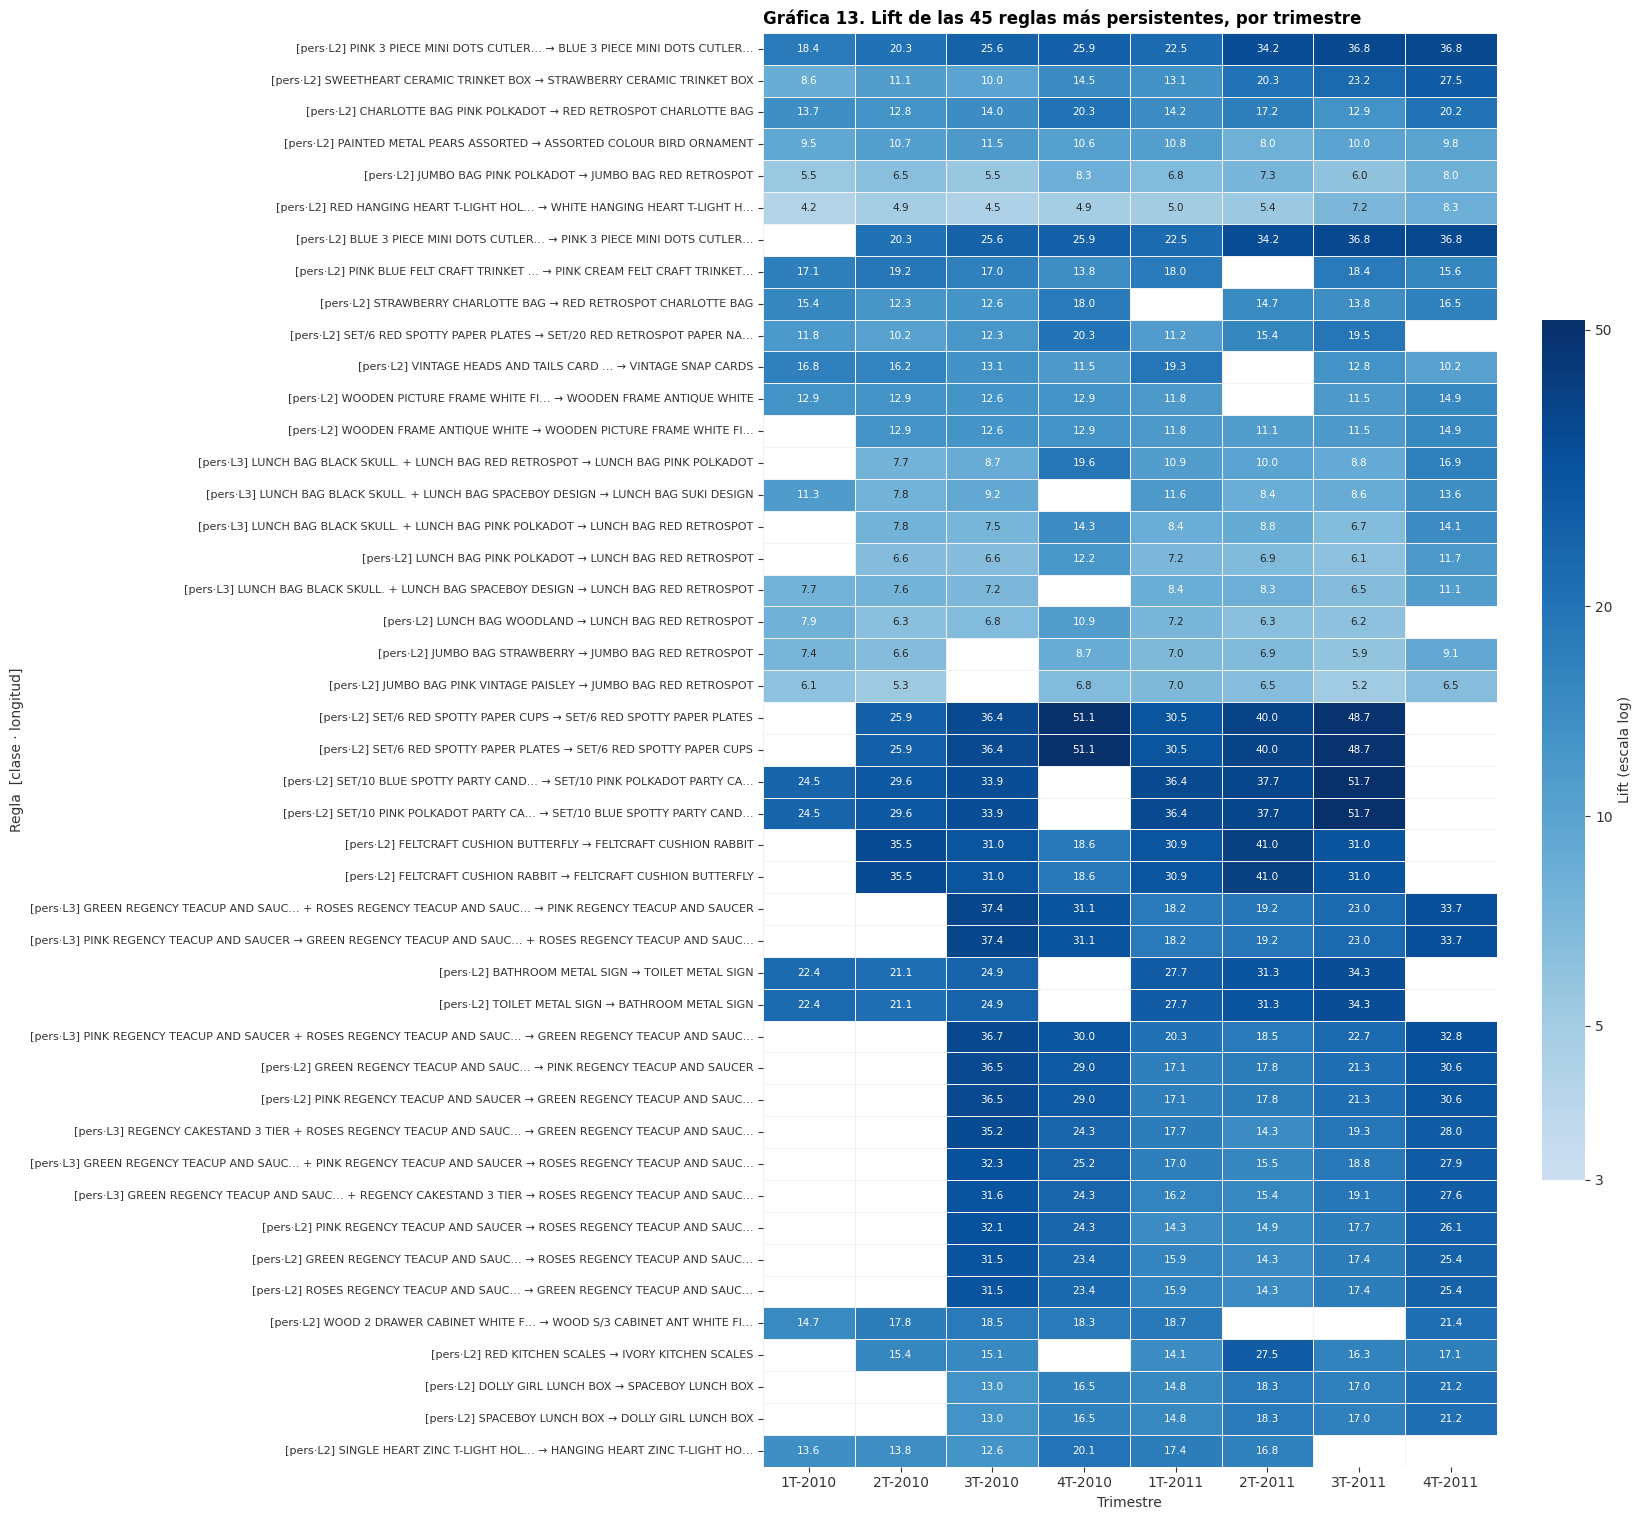

Reglas estacionales (mismo trimestre del año en ambos años), de mayor a menor lift medio:


,regla,longitud,trimestres_en,lift medio
0,CHRISTMAS GINGHAM STAR → CHRISTMAS GINGHAM TREE,2,"4T-2010, 4T-2011",37.64
1,CHRISTMAS GINGHAM TREE → CHRISTMAS GINGHAM STAR,2,"4T-2010, 4T-2011",37.64
2,HEART WOODEN CHRISTMAS DECORA… → STAR WOODEN CHRISTMAS DECORAT…,2,"4T-2010, 4T-2011",34.20
3,STAR WOODEN CHRISTMAS DECORAT… → HEART WOODEN CHRISTMAS DECORA…,2,"4T-2010, 4T-2011",34.20
4,BLUE POLKADOT PLATE → BLUE POLKADOT CUP,2,"1T-2010, 1T-2011",33.92
5,BLUE POLKADOT CUP → BLUE POLKADOT PLATE,2,"1T-2010, 1T-2011",33.92
6,BLUE POLKADOT BOWL → BLUE POLKADOT PLATE,2,"1T-2010, 1T-2011",33.14
7,BLUE POLKADOT PLATE → BLUE POLKADOT BOWL,2,"1T-2010, 1T-2011",33.14
8,PINK FLORAL FELTCRAFT SHOULDE… → RED FLORAL FELTCRAFT SHOULDER…,2,"4T-2010, 4T-2011",30.37
9,RED FLORAL FELTCRAFT SHOULDER… → PINK FLORAL FELTCRAFT SHOULDE…,2,"4T-2010, 4T-2011",30.37


In [51]:
# Heatmap reglas × trimestres (color = lift, vacío = la regla no pasa los umbrales en ese trimestre)
TOP_HEATMAP = 45
orden = info.sort_values(["trimestres", "lift medio", "regla"], ascending=[False, False, True]).head(TOP_HEATMAP)
datos = lift_trim.loc[orden.index]
fig, ax = plt.subplots(figsize=(17, 0.3 * TOP_HEATMAP + 1.8))
sns.heatmap(datos.to_numpy(dtype=float), ax=ax, cmap=CMAP_SEC, norm=LogNorm(vmin=LIFT_MIN, vmax=np.nanmax(datos.to_numpy(dtype=float))),
            annot=True, fmt=".1f", annot_kws={"fontsize": 7.5}, linewidths=0.6, linecolor="#F2F2F2",
            cbar_kws={"label": "Lift (escala log)", "shrink": 0.6}, mask=datos.isna().to_numpy())
ax.set_xticks(np.arange(n_q) + 0.5, labels=TRIM_ANALISIS, rotation=0)
ax.set_yticks(np.arange(len(orden)) + 0.5, rotation=0, fontsize=8,
              labels=[f"[{c[:4]}·L{l}] {r}" for r, c, l in zip(orden["regla"], orden["clase"], orden["longitud"])])
marcas_log(ax.collections[0].colorbar, LIFT_MIN, np.nanmax(datos.to_numpy(dtype=float)))
estilo_ejes(ax, f"Gráfica 13. Lift de las {TOP_HEATMAP} reglas más persistentes, por trimestre", "Trimestre",
            "Regla  [clase · longitud]", rejilla=None)
plt.tight_layout()
plt.show()

print("Reglas estacionales (mismo trimestre del año en ambos años), de mayor a menor lift medio:")
est = info[info["clase"] == "estacional"].sort_values(["lift medio", "regla"], ascending=[False, True])
display(est[["regla", "longitud", "trimestres_en", "lift medio"]].head(15).round(2).reset_index(drop=True))

**Observaciones: comparación entre trimestres**

- **Pocas reglas se repiten.** Las 9,320 reglas corresponden a **6,471 reglas distintas**. **4,771** aparecen en un solo
  trimestre y solo **6** aparecen en los 8.
- **Clasificación** (tabla clase × longitud):
  - **80 persistentes** (49 de longitud 2, 31 de longitud 3, **ninguna de longitud 4+**);
  - **493 intermitentes**;
  - **161 estacionales**;
  - **5,737 puntuales** (el **88.7 %**).
  - **Las reglas largas son las menos estables:** 3,095 de las 3,237 reglas distintas de longitud 4+ son puntuales.
  - Las puntuales tienen el lift mediano más alto (**15.55** contra **10.78** de las persistentes). Muchas son juegos
    completos de un solo trimestre, con lift alto y poco respaldo.
- **Gráfica 13 (las 45 más persistentes, todas de la clase persistente).**
  - Las 6 que aparecen en los 8 trimestres son pares de diseños o de complementos:
    - `PINK → BLUE 3 PIECE MINI DOTS CUTLERY`;
    - `SWEETHEART → STRAWBERRY CERAMIC TRINKET BOX`;
    - `CHARLOTTE BAG PINK POLKADOT → RED RETROSPOT`;
    - `PAINTED METAL PEARS → ASSORTED COLOUR BIRD ORNAMENT`;
    - `JUMBO BAG PINK POLKADOT → RED RETROSPOT`;
    - `RED → WHITE HANGING HEART T-LIGHT HOLDER`.
  - El lift **no es constante**:
    - los cubiertos `MINI DOTS` suben de **18.4** (1T-2010) a **36.8** (3T-2011 y 4T-2011);
    - `RED → WHITE HANGING HEART` sube de **4.2** a **8.3**;
    - las bolsas `JUMBO BAG` se mueven entre **5.5** y **8.3**.
  - Hay huecos que coinciden con la temporada: `SET/6 RED SPOTTY PAPER CUPS ↔ PLATES` (lift de **25.9** a **51.1**) falta
    en el 1T-2010 y en el 4T-2011, y la vajilla `REGENCY` solo aparece a partir del 3T-2010.
- **Reglas estacionales.** Siguen el calendario de la tienda:
  - **4T:** `CHRISTMAS GINGHAM STAR ↔ TREE` (lift medio **37.64**), decoraciones de madera de Navidad y `ROCKING HORSE`;
  - **2T (primavera y verano):** `RED METAL BEACH SPADE ↔ BOYS VINTAGE TIN SEASIDE BUCKET` (**30.24**);
  - **1T:** la vajilla `BLUE POLKADOT` (**33.92**);
  - **3T:** `36 DOILIES VINTAGE CHRISTMAS → 60 CAKE CASES VINTAGE CHRISTMAS` (**27.89**), artículos navideños comprados en
    el 3T, coherente con mayoristas que se surten antes de la temporada.
- **Cuidado.** Que una regla falte en un trimestre significa que no pasó $s$ = 1 %, confianza 0.5 o lift 3. No significa
  que la asociación desaparezca: varias "intermitentes" pueden estar justo por debajo de un umbral.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · EVALUACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">8. Evaluación crítica de las reglas</span></div>


Que una regla pase los umbrales no la hace útil. Esta sección revisa cuatro problemas.

1. **Variantes del mismo producto o línea.** Muchas reglas de lift alto relacionan productos casi idénticos: el mismo
   diseño en otro color (`GREEN REGENCY TEACUP AND SAUCER` → `PINK REGENCY TEACUP AND SAUCER`) o el mismo artículo con otro
   sufijo de código (`85099B` / `85099C`). Son reales (el cliente compra la colección completa), pero son **obvias** y
   aportan poco como recomendación. **Criterio:** dos productos son variantes si comparten el código base de 5 dígitos y
   difieren en el sufijo, **o** si sus descripciones son idénticas al quitar las palabras de color. Una regla es "de
   variantes" si algún producto del antecedente es variante de alguno del consecuente. El criterio no detecta variantes
   que cambian el estampado y el color a la vez (por ejemplo, `RED RETROSPOT` / `PINK POLKADOT`), así que el conteo es un
   **mínimo**.
2. **Respaldo débil.** El soporte relativo oculta cuántas facturas hay detrás. Además, varias facturas pueden ser **del
   mismo cliente** (un mayorista que repite su pedido), y en ese caso la regla refleja los hábitos de unos pocos
   compradores, no un patrón general. Se cuentan las reglas con pocas facturas y con pocos clientes distintos.
3. **Redundancia** de las reglas largas (resumen de la sección 6).
4. **Correlación ≠ causalidad** (se discute en las Observaciones).

,reglas,lift_mediano,confianza_mediana,facturas_medianas,% de las reglas
tipo,,,,,
Resto,7819,12.125,0.653,52.0,83.89
Variantes del mismo producto/línea,1501,33.644,0.750,56.0,16.11


tipo,% Resto,% Variantes del mismo producto/línea
trimestre,,
1T-2010,75.1,24.9
2T-2010,59.0,41.0
3T-2010,79.0,21.0
4T-2010,77.7,22.3
1T-2011,81.2,18.8
2T-2011,88.5,11.5
3T-2011,93.8,6.2
4T-2011,89.8,10.2


Por longitud (% de reglas de variantes): {'2': 21.8, '3': 13.6, '4+': 15.7}


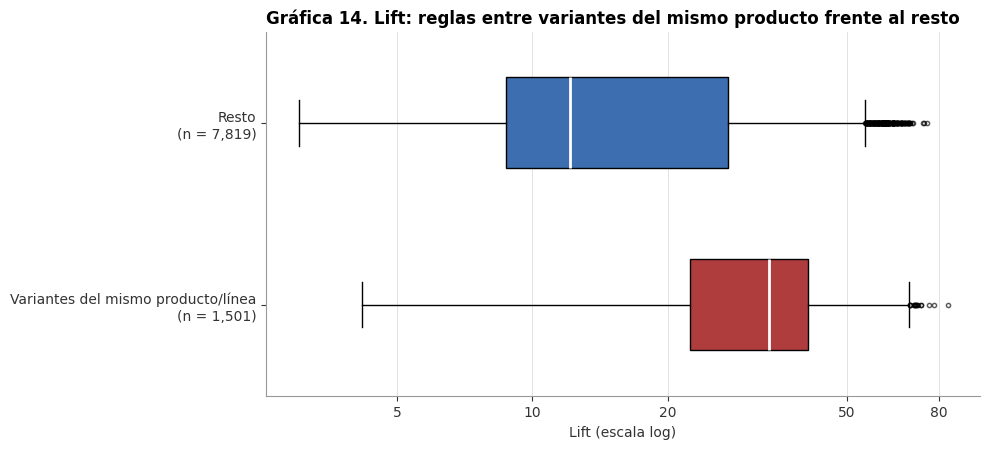

Ejemplos de reglas entre variantes (mayor número de facturas):


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes
0,RED HANGING HEART T-LIGHT HOLDER → WHITE HANGING HEART T-LIGHT HOLDER,4T-2010,2,4.46,0.678,4.909,271,199
1,ALARM CLOCK BAKELIKE GREEN → ALARM CLOCK BAKELIKE RED,4T-2010,2,3.31,0.679,13.519,201,132
2,ALARM CLOCK BAKELIKE RED → ALARM CLOCK BAKELIKE GREEN,4T-2010,2,3.31,0.659,13.519,201,132
3,JUMBO BAG STRAWBERRY → JUMBO BAG RED RETROSPOT,2T-2010,2,4.35,0.678,6.634,181,131
4,GREEN REGENCY TEACUP AND SAUCER → PINK REGENCY TEACUP AND SAUCER,2T-2011,2,3.56,0.744,17.816,145,123
5,PINK REGENCY TEACUP AND SAUCER → GREEN REGENCY TEACUP AND SAUCER,2T-2011,2,3.56,0.853,17.816,145,123
6,JUMBO BAG BAROQUE BLACK WHITE → JUMBO BAG RED RETROSPOT,4T-2010,2,2.29,0.599,7.486,139,113
7,CHILDS GARDEN TROWEL BLUE → CHILDS GARDEN TROWEL PINK,2T-2010,2,3.15,0.929,27.212,131,120


In [52]:
# Variantes del mismo producto o línea: mismo código base o misma descripción salvo el color
COLORES = {"RED", "BLUE", "PINK", "GREEN", "WHITE", "BLACK", "IVORY", "CREAM", "YELLOW", "ORANGE", "PURPLE", "LILAC",
           "BROWN", "GREY", "GRAY", "SILVER", "GOLD", "TURQUOISE", "AQUA", "NATURAL", "CHOCOLATE", "LAVENDER", "MAUVE",
           "BEIGE", "TEAL", "PASTEL", "MINT", "CERISE", "FUSCHIA", "FUCHSIA", "MAGENTA", "COPPER", "JADE", "NAVY"}


def codigo_base(codigo):
    """Prefijo numérico de 5 dígitos del StockCode (85099B → 85099); si no lo tiene, el código completo."""
    m = re.match(r"^(\d{5})", codigo)
    return m.group(1) if m else codigo


def sin_color(codigo):
    """Descripción del producto sin las palabras de color."""
    return " ".join(p for p in etiquetas.get(codigo, codigo).split() if p not in COLORES)


def son_variantes(x, y):
    """
    Indica si dos StockCode son variantes del mismo producto o línea.

    Criterio: comparten el código base de 5 dígitos y difieren en el sufijo (85099B / 85099C), o sus
    descripciones son idénticas al quitar las palabras de color (GREEN / PINK REGENCY TEACUP AND SAUCER).
    """
    if x == y:
        return False
    return codigo_base(x) == codigo_base(y) or sin_color(x) == sin_color(y)


reglas["variantes"] = [any(son_variantes(x, y) for x in a for y in c) for a, c in zip(reglas["antecedents"], reglas["consequents"])]
reglas["tipo"] = np.where(reglas["variantes"], "Variantes del mismo producto/línea", "Resto")
comp_var = reglas.groupby("tipo").agg(reglas=("regla", "size"), lift_mediano=("lift", "median"),
                                      confianza_mediana=("confidence", "median"), facturas_medianas=("facturas", "median"))
comp_var["% de las reglas"] = (100 * comp_var["reglas"] / len(reglas)).round(2)
display(comp_var.round(3))
display(pd.crosstab(reglas["trimestre"], reglas["tipo"], normalize="index").reindex(TRIM_ANALISIS).mul(100).round(1)
        .rename(columns=lambda c: f"% {c}"))
print("Por longitud (% de reglas de variantes):",
      reglas.groupby("grupo")["variantes"].mean().mul(100).round(1).to_dict())

fig, ax = plt.subplots(figsize=(10, 4.6))
tipos = ["Variantes del mismo producto/línea", "Resto"]
partes = ax.boxplot([reglas.loc[reglas["tipo"] == t, "lift"] for t in tipos], vert=False, widths=0.5, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2), flierprops=dict(marker="o", markersize=3, alpha=0.4))
for caja, color in zip(partes["boxes"], [ROJO, AZUL]):
    caja.set_facecolor(color)
ax.set_yticks([1, 2], [f"{t}\n(n = {(reglas['tipo'] == t).sum():,})" for t in tipos])
ax.set_xscale("log")
marcas_log(ax.xaxis, reglas["lift"].min(), reglas["lift"].max())
estilo_ejes(ax, "Gráfica 14. Lift: reglas entre variantes del mismo producto frente al resto", "Lift (escala log)",
            None, rejilla="x")
plt.tight_layout()
plt.show()

print("Ejemplos de reglas entre variantes (mayor número de facturas):")
display(tabla_reglas(reglas[reglas["variantes"]].sort_values(["facturas", "regla"], ascending=[False, True])
                     .drop_duplicates(["antecedents", "consequents"]).head(8)))

In [53]:
# Reglas respaldadas por pocas facturas o por pocos clientes
POCAS_FACTURAS = 50
POCOS_CLIENTES = 5
reglas["clientes_por_factura"] = reglas["clientes"] / reglas["facturas"]
debiles = pd.DataFrame({
    "reglas": reglas.groupby("trimestre").size(),
    f"< {POCAS_FACTURAS} facturas": reglas.assign(x=reglas["facturas"] < POCAS_FACTURAS).groupby("trimestre")["x"].sum(),
    f"≤ {POCOS_CLIENTES} clientes": reglas.assign(x=reglas["clientes"] <= POCOS_CLIENTES).groupby("trimestre")["x"].sum(),
    "facturas mínimas": reglas.groupby("trimestre")["facturas"].min(),
    "facturas medianas": reglas.groupby("trimestre")["facturas"].median(),
}).reindex(TRIM_ANALISIS)
debiles["σ del trimestre"] = [MIN_SUP_TRIM[q] * N_trim[q] for q in TRIM_ANALISIS]
display(debiles.round(1))
print(f"Total: {(reglas['facturas'] < POCAS_FACTURAS).sum():,} reglas con < {POCAS_FACTURAS} facturas "
      f"({pct((reglas['facturas'] < POCAS_FACTURAS).mean())}) | {(reglas['clientes'] <= POCOS_CLIENTES).sum():,} con ≤ "
      f"{POCOS_CLIENTES} clientes ({pct((reglas['clientes'] <= POCOS_CLIENTES).mean())})")
print(f"Correlación de Spearman entre lift y facturas que respaldan la regla: "
      f"{reglas[['lift', 'facturas']].corr(method='spearman').iloc[0, 1]:.3f}")
print("Reglas de lift alto con menos clientes distintos (facturas repetidas de los mismos compradores):")
display(tabla_reglas(reglas.sort_values(["clientes", "lift", "regla"], ascending=[True, False, True]).head(8)))

print("Resumen de redundancia de las reglas largas (sección 6):")
print(f"  reglas de longitud ≥ 3: {largas.sum():,} | redundantes: {reglas['redundante'].sum():,} "
      f"({pct(reglas['redundante'].sum() / max(largas.sum(), 1))}) | reglas finales no redundantes: {(~reglas['redundante']).sum():,}")

,reglas,< 50 facturas,≤ 5 clientes,facturas mínimas,facturas medianas,σ del trimestre
trimestre,,,,,,
1T-2010,337,217,0,36,43.0,35.6
2T-2010,1262,333,0,42,61.0,41.6
3T-2010,857,330,22,43,52.0,43.0
4T-2010,394,0,0,61,83.0,60.7
1T-2011,1003,856,0,33,37.0,32.9
2T-2011,1658,669,0,41,58.0,40.7
3T-2011,3377,1464,0,44,51.0,43.3
4T-2011,432,0,0,54,68.0,53.2


Total: 3,869 reglas con < 50 facturas (41.51 %) | 22 con ≤ 5 clientes (0.24 %)
Correlación de Spearman entre lift y facturas que respaldan la regla: -0.175
Reglas de lift alto con menos clientes distintos (facturas repetidas de los mismos compradores):


,regla,trimestre,longitud,soporte (%),confianza,lift,facturas,clientes
0,EMPIRE BIRTHDAY CARD + WOODEN FRAME ANTIQUE WHITE → WOOD S/3 CABINET ANT WHITE FINISH + WOODEN P...,3T-2010,4,1.0,0.956,48.306,43,4
1,WOOD S/3 CABINET ANT WHITE FINISH + WOODEN PICTURE FRAME WHITE FINISH → EMPIRE BIRTHDAY CARD + W...,3T-2010,4,1.0,0.506,48.306,43,4
2,EMPIRE BIRTHDAY CARD + WOODEN PICTURE FRAME WHITE FINISH → WOOD S/3 CABINET ANT WHITE FINISH + W...,3T-2010,4,1.0,0.956,47.196,43,4
3,WOOD S/3 CABINET ANT WHITE FINISH + WOODEN FRAME ANTIQUE WHITE + WOODEN PICTURE FRAME WHITE FINI...,3T-2010,4,1.0,0.573,36.770,43,4
4,EMPIRE BIRTHDAY CARD → WOOD S/3 CABINET ANT WHITE FINISH + WOODEN FRAME ANTIQUE WHITE + WOODEN P...,3T-2010,4,1.0,0.642,36.770,43,4
5,EMPIRE BIRTHDAY CARD → WOOD S/3 CABINET ANT WHITE FINISH + WOODEN PICTURE FRAME WHITE FINISH,3T-2010,3,1.0,0.642,32.444,43,4
6,WOOD S/3 CABINET ANT WHITE FINISH + WOODEN PICTURE FRAME WHITE FINISH → EMPIRE BIRTHDAY CARD,3T-2010,3,1.0,0.506,32.444,43,4
7,EMPIRE BIRTHDAY CARD → WOOD S/3 CABINET ANT WHITE FINISH + WOODEN FRAME ANTIQUE WHITE,3T-2010,3,1.0,0.642,31.699,43,4


Resumen de redundancia de las reglas largas (sección 6):
  reglas de longitud ≥ 3: 7,446 | redundantes: 2,951 (39.63 %) | reglas finales no redundantes: 6,369


**Observaciones: evaluación crítica**

- **Variantes del mismo producto o línea.**
  - **1,501** reglas (**16.11 %**) relacionan variantes según el criterio (mismo código base o misma descripción salvo el
    color).
  - Su lift mediano es **33.6**, contra **12.1** del resto, y su confianza mediana **0.750** contra **0.653**.
    Gráfica 14: las cajas casi no se traslapan.
  - **Las reglas de lift más alto son, en buena parte, "quien compra el rosa compra el azul"**: `GREEN ↔ PINK REGENCY TEACUP
    AND SAUCER` (lift **17.816**, **145 facturas**), `ALARM CLOCK BAKELIKE GREEN ↔ RED` (**13.519**),
    `CHILDS GARDEN TROWEL BLUE → PINK` (**27.21**).
  - Son ciertas, pero triviales para recomendar o acomodar productos: el cliente compra la colección.
  - El porcentaje varía por trimestre: **41.0 %** en 2T-2010 y **6.2 %** en 3T-2011. Las loncheras del 3T-2011 tienen
    diseños con nombres distintos (`SPACEBOY`, `SUKI`, `VINTAGE DOILY`), que el criterio no reconoce como variantes.
  - El 16.11 % es, por lo tanto, un **mínimo**: el criterio no capta líneas que cambian de nombre de diseño.
- **Respaldo débil.**
  - **3,869** reglas (**41.51 %**) se apoyan en **menos de 50 facturas**. Con unas 40 facturas, el error estándar de una
    confianza cercana a 0.6 es de unos 0.08, así que diferencias de esa magnitud entre reglas no son significativas.
  - El problema se concentra en los trimestres pequeños: en 1T-2011, **856** de **1,003** reglas tienen menos de 50
    facturas ($\sigma$ = 32.9). En los 4T no hay ninguna, porque $\sigma$ ≥ 53.
  - Hay una correlación débil y negativa entre lift y facturas (Spearman **−0.175**): las reglas más llamativas tienden a
    ser las menos respaldadas.
- **Pocos clientes.** Casi todas las reglas vienen de muchos compradores distintos, pero hay **22** (**0.24 %**) respaldadas
  por **5 clientes o menos**, todas del 3T-2010. Por ejemplo, `EMPIRE BIRTHDAY CARD + WOODEN FRAME ANTIQUE WHITE →
  WOOD S/3 CABINET ANT WHITE FINISH + …` tiene lift **48.306** y **43 facturas**, pero de solo **4 clientes**: es el pedido
  repetido de unos pocos mayoristas, no un patrón de la clientela. Sin revisar los clientes, esta regla parecería sólida.
- **Redundancia.** De **7,446** reglas de longitud ≥ 3, **2,951** (**39.63 %**) no mejoran ni la confianza ni el lift de
  sus sub-reglas. Quitándolas quedan **6,369** reglas no redundantes. Las de longitud 3 suelen aportar; las de 4+, en su
  mayoría no.
- **Correlación ≠ causalidad.** Un lift de 30 entre `PINK` y `BLUE REGENCY TEACUP` no significa que comprar una taza
  *cause* la compra de la otra. Las co-ocurrencias se explican por factores comunes:
  - el **catálogo** (los productos se presentan juntos como colección);
  - el **cliente mayorista** (surte varios diseños para revender);
  - la **temporada** (Navidad o regreso a clases empujan las dos ventas a la vez).
  - Para saber si acomodar productos juntos o recomendarlos *aumenta* las ventas haría falta un experimento (por ejemplo,
    una prueba A/B en la tienda en línea), no más minería.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">MINERÍA · CIERRE</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">9. Conclusiones y limitaciones</span></div>


### Conclusiones

1. **La definición de transacción importa tanto como el algoritmo.**
   - Las **2,922** facturas sin `Customer ID` (7.39 % de las facturas, 22.78 % de los pares factura-producto) incluyen
     pedidos gigantes con un núcleo repetido.
   - Solo **26** de ellas, de enero de 2011, que comparten **18** productos, bastan para que FP-Growth pase de **7,090** a
     **291,886** itemsets en el 1T-2011 al bajar $s$ de 0.75 % a 0.7 %.
   - Excluirlas eliminó la explosión y la cola de canastas gigantes sin cambiar la canasta mediana (**15** productos).
2. **FP-Growth es adecuado y barato en este problema.**
   - Los datos son dispersos (densidad **0.0045**) y, con $s$ = 1 %, la pasada 1 reduce el universo a entre 575 y 741
     productos por trimestre.
   - Todo el barrido de 56 corridas tarda del orden de medio minuto.
   - Su punto débil, visto aquí, no es la generación de candidatos, que no existe, sino la **enumeración de patrones**
     cuando muchas transacciones comparten bloques grandes de ítems.
3. **El soporte mínimo se eligió por los datos: $s$ = 1 %, común a los 8 trimestres.** Es el valor más bajo en el que ningún
   trimestre produce cadenas anómalas (longitud máxima ≤ 6) y todos conservan itemsets de longitud ≥ 3 (de 63 a 946). El
   umbral común hace comparables los trimestres.
4. **Las reglas confiables son, sobre todo, de colecciones.**
   - Con confianza ≥ 0.5 y lift ≥ 3 quedan **9,320** reglas (**6,471** distintas).
   - Las más respaldadas son navideñas (cadenas de papel, corazones portavelas, decoraciones de madera) y de bolsas y
     loncheras.
   - Las de mayor lift son juegos completos y variantes de color: el **16.11 %** de las reglas son variantes y su lift
     mediano (**33.6**) casi triplica el del resto (**12.1**).
5. **Las reglas largas aportan en longitud 3, no tanto en 4+.** El **73.9 %** de las reglas de longitud 3 mejora la confianza
   de sus sub-reglas, pero el **56.4 %** de las de longitud 4+ es redundante.
6. **La temporada manda.**
   - Solo **80** reglas son persistentes (6 en los 8 trimestres) y el **88.7 %** es puntual.
   - Hay reglas estacionales claras: Navidad en el 4T (y su preparación en el 3T), playa en el 2T y loncheras en el 3T.
   - Las recomendaciones de "productos que se compran juntos" deberían actualizarse por temporada.

### Limitaciones

- **Exclusión de las facturas sin cliente:** si una parte eran compras reales de clientes no registrados, sus patrones
  quedan fuera.
- **Trimestres incompletos:**
  - el 4T-2009 se excluyó;
  - el 4T-2011 termina el 09/12/2011, así que sus conteos y su mezcla de productos no son comparables uno a uno con el
    4T-2010.
- **Sensibilidad a los umbrales:**
  - la clasificación persistente, estacional o puntual depende de $s$, de la confianza y del lift;
  - una regla "ausente" puede estar justo debajo del umbral;
  - con $s$ por trimestre los resultados de la sección 7 cambiarían.
- **Respaldo:** el 41.51 % de las reglas tiene menos de 50 facturas. Las diferencias pequeñas de confianza o lift entre
  ellas no son significativas.
- **Ítems y etiquetas:**
  - se ignora `Quantity`: una factura con 1 unidad pesa lo mismo que una con 1,000;
  - el ítem es el `StockCode`, así que un producto que cambió de código cuenta como dos, y los 592 códigos con varias
    descripciones se leen con su nombre más frecuente.
- **Criterio de variantes:** es un mínimo. No detecta diseños de una misma línea con nombres distintos.
- **Correlación, no causalidad:** las reglas describen co-ocurrencias. Su efecto sobre las ventas requeriría un
  experimento.